In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import fisher_exact, false_discovery_control

# Optional: Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data/digital_marketing_dataset_30k.csv')

# Print basic info
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nColumn names:")
print(df.columns.tolist())

print(f"\nData types:")
print(df.dtypes)

Dataset shape: 30000 rows, 35 columns

First few rows:
         date  year  month month_name  week day_of_week  post_hour  season  \
0  08/04/2023  2023      4        Apr    14         Sat          7  Spring   
1  28/04/2025  2025      4        Apr    18         Mon         12  Spring   
2  18/12/2024  2024     12        Dec    51         Wed         10  Winter   
3  26/04/2024  2024      4        Apr    17         Fri         20  Spring   
4  19/04/2024  2024      4        Apr    16         Fri         22  Spring   

   is_holiday is_holiday (text)  ...      ad_id     ad_name   spend  \
0           0                No  ...  AD8747890  In-Feed_V1  871.17   
1           0                No  ...  AD2884130     Feed_V9  362.55   
2           0                No  ...  AD5656772  Display_V7  362.09   
3           0                No  ...  AD3443678  Stories_V2   54.45   
4           0                No  ...  AD8461978    Reels_V8   56.18   

  impressions  reach frequency clicks conversions

In [3]:
# Check unique platforms
print("Unique platforms:")
print(df['platform'].value_counts())

# Check how many unique platforms
n_platforms = df['platform'].nunique()
print(f"\nTotal unique platforms: {n_platforms}")

# Check for missing values in key columns
key_columns = ['platform', 'spend', 'clicks', 'conversions', 'revenue']
print(f"\nMissing values in key columns:")
print(df[key_columns].isnull().sum())

# Check data types for metric columns
metric_columns = ['spend', 'impressions', 'clicks', 'conversions', 'revenue']
print(f"\nData types for metric columns:")
print(df[metric_columns].dtypes)

Unique platforms:
platform
Meta              6867
Google Search     5709
TikTok            5467
LinkedIn          5339
Snapchat          3603
Google Display    3015
Name: count, dtype: int64

Total unique platforms: 6

Missing values in key columns:
platform       0
spend          0
clicks         0
conversions    0
revenue        0
dtype: int64

Data types for metric columns:
spend          float64
impressions      int64
clicks           int64
conversions      int64
revenue        float64
dtype: object


In [4]:
# Group by platform and calculate totals
platform_summary = df.groupby('platform').agg({
    'spend': 'sum',
    'impressions': 'sum', 
    'clicks': 'sum',
    'conversions': 'sum',
    'revenue': 'sum'
}).reset_index()

# Calculate metrics
platform_summary['CTR'] = platform_summary['clicks'] / platform_summary['impressions']
platform_summary['Conversion_Rate'] = platform_summary['conversions'] / platform_summary['clicks']
platform_summary['CPA'] = platform_summary['spend'] / platform_summary['conversions']
platform_summary['ROAS'] = platform_summary['revenue'] / platform_summary['spend']

# Round for readability
platform_summary = platform_summary.round(2)

print("Platform Performance Summary:")
print(platform_summary)


Platform Performance Summary:
         platform       spend  impressions    clicks  conversions  \
0  Google Display  1157077.08    267512354   1809793         9109   
1   Google Search  2744251.20    203859987  11515557       216694   
2        LinkedIn  2556360.66    103157407    685644         5588   
3            Meta  2636602.54    374732945   4439765        41978   
4        Snapchat  1450865.95    347175290   3230264        21148   
5          TikTok  2091251.63    405325464   3936117        28281   

       revenue   CTR  Conversion_Rate     CPA  ROAS  
0    328505.21  0.01             0.01  127.03  0.28  
1  10362175.17  0.06             0.02   12.66  3.78  
2    276970.44  0.01             0.01  457.47  0.11  
3   1640105.78  0.01             0.01   62.81  0.62  
4    669736.81  0.01             0.01   68.61  0.46  
5    993860.85  0.01             0.01   73.95  0.48  


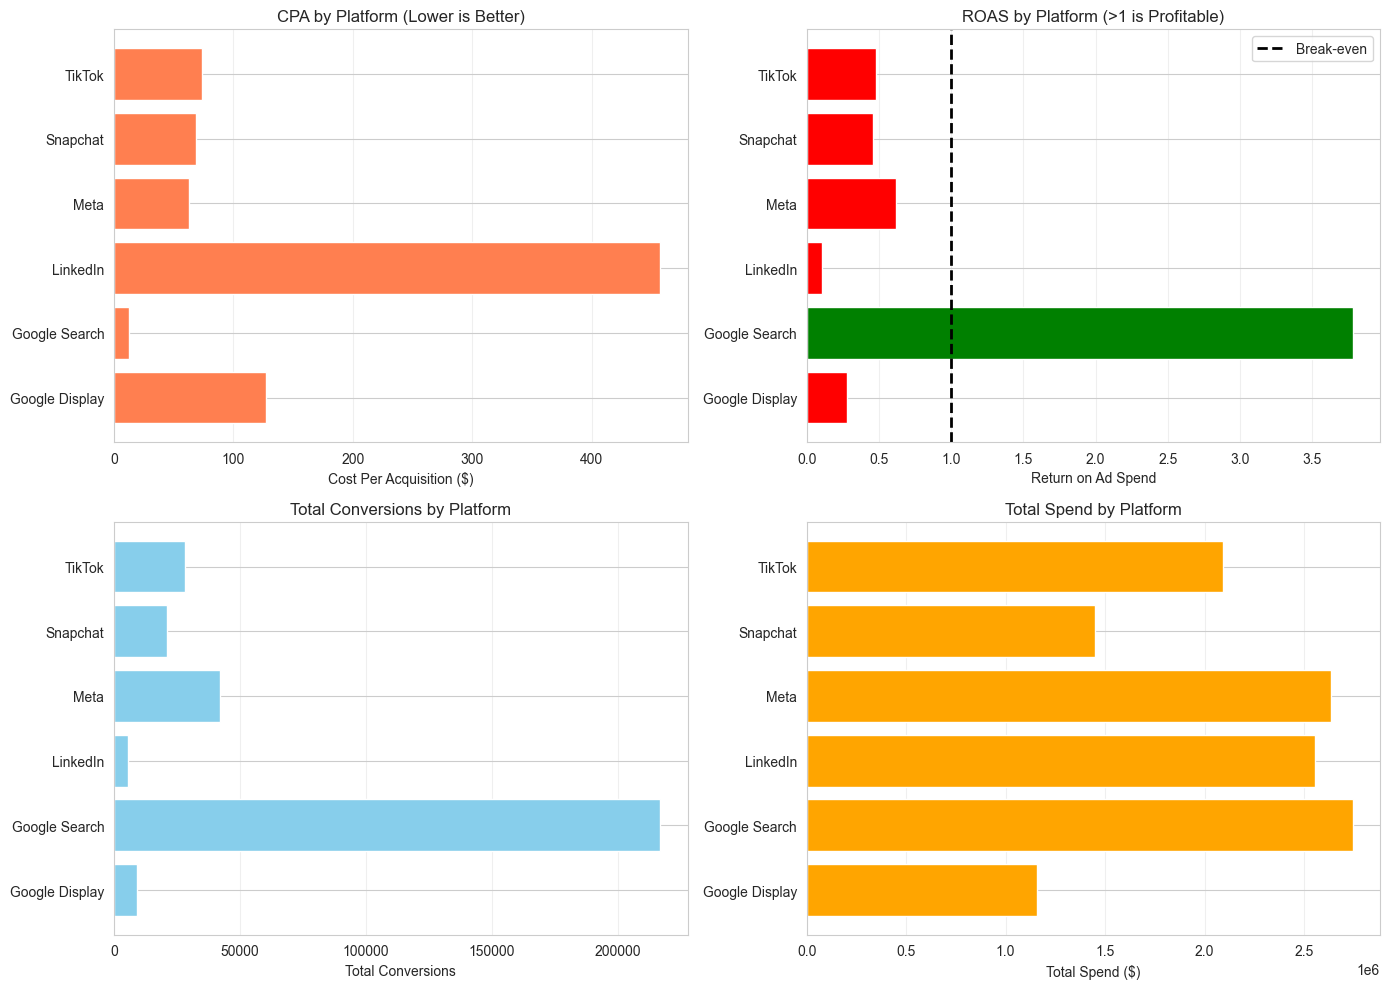

✓ Visualization saved to results/platform_metrics_overview.png


In [5]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CPA by Platform
axes[0, 0].barh(platform_summary['platform'], platform_summary['CPA'], color='coral')
axes[0, 0].set_xlabel('Cost Per Acquisition ($)')
axes[0, 0].set_title('CPA by Platform (Lower is Better)')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. ROAS by Platform
colors = ['green' if x > 1 else 'red' for x in platform_summary['ROAS']]
axes[0, 1].barh(platform_summary['platform'], platform_summary['ROAS'], color=colors)
axes[0, 1].axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='Break-even')
axes[0, 1].set_xlabel('Return on Ad Spend')
axes[0, 1].set_title('ROAS by Platform (>1 is Profitable)')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Total Conversions by Platform
axes[1, 0].barh(platform_summary['platform'], platform_summary['conversions'], color='skyblue')
axes[1, 0].set_xlabel('Total Conversions')
axes[1, 0].set_title('Total Conversions by Platform')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Total Spend by Platform
axes[1, 1].barh(platform_summary['platform'], platform_summary['spend'], color='orange')
axes[1, 1].set_xlabel('Total Spend ($)')
axes[1, 1].set_title('Total Spend by Platform')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/platform_metrics_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to results/platform_metrics_overview.png")

In [6]:
# Calculate daily-level metrics (important for t-tests later)
# We need per-day data, not just totals

# First, let's see if we have multiple rows per platform per day
print("Sample of daily data structure:")
print(df[['date', 'platform', 'spend', 'conversions']].head(10))

# Calculate daily CPA (we'll use this for t-tests)
# Handle division by zero
df['daily_CPA'] = np.where(df['conversions'] > 0, 
                            df['spend'] / df['conversions'], 
                            np.nan)

# Calculate daily conversion rate
df['daily_conv_rate'] = np.where(df['clicks'] > 0,
                                   df['conversions'] / df['clicks'],
                                   np.nan)

# Calculate daily ROAS
df['daily_ROAS'] = np.where(df['spend'] > 0,
                             df['revenue'] / df['spend'],
                             np.nan)

print(f"\nDaily metrics calculated!")
print(f"Rows with valid CPA: {df['daily_CPA'].notna().sum()}")
print(f"Rows with valid conversion rate: {df['daily_conv_rate'].notna().sum()}")
print(f"Rows with valid ROAS: {df['daily_ROAS'].notna().sum()}")

Sample of daily data structure:
         date        platform    spend  conversions
0  08/04/2023          TikTok   871.17            0
1  28/04/2025            Meta   362.55            0
2  18/12/2024  Google Display   362.09            7
3  26/04/2024        Snapchat    54.45            0
4  19/04/2024            Meta    56.18            0
5  30/07/2025            Meta    53.98            2
6  05/04/2023        LinkedIn  1242.00            0
7  03/02/2025          TikTok   129.16            0
8  09/08/2023            Meta   935.07            0
9  14/04/2023          TikTok  1033.53           30

Daily metrics calculated!
Rows with valid CPA: 15640
Rows with valid conversion rate: 30000
Rows with valid ROAS: 30000


CPA distribution stats (capped at 99th percentile: $1694.11):
                 count    mean     std    min    25%     50%     75%      max
platform                                                                     
Google Display  1486.0  266.72  356.35   9.36  46.44   93.61  364.15  1694.11
Google Search   4094.0  201.41  301.46   0.62   5.58   81.60  272.20  1694.11
LinkedIn        1352.0  343.79  399.43  19.13  83.52  167.40  439.04  1694.11
Meta            3638.0  244.10  371.11   4.15  20.65   42.42  344.69  1694.11
Snapchat        2077.0  246.15  356.50   4.62  25.38   56.65  336.48  1694.11
TikTok          2993.0  246.34  362.11   5.05  26.22   51.19  340.28  1694.11


C:\Users\pbiai\AppData\Local\Temp\ipykernel_45384\523060050.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df_clean_cpa[df_clean_cpa['platform'] == p]['daily_CPA_capped']


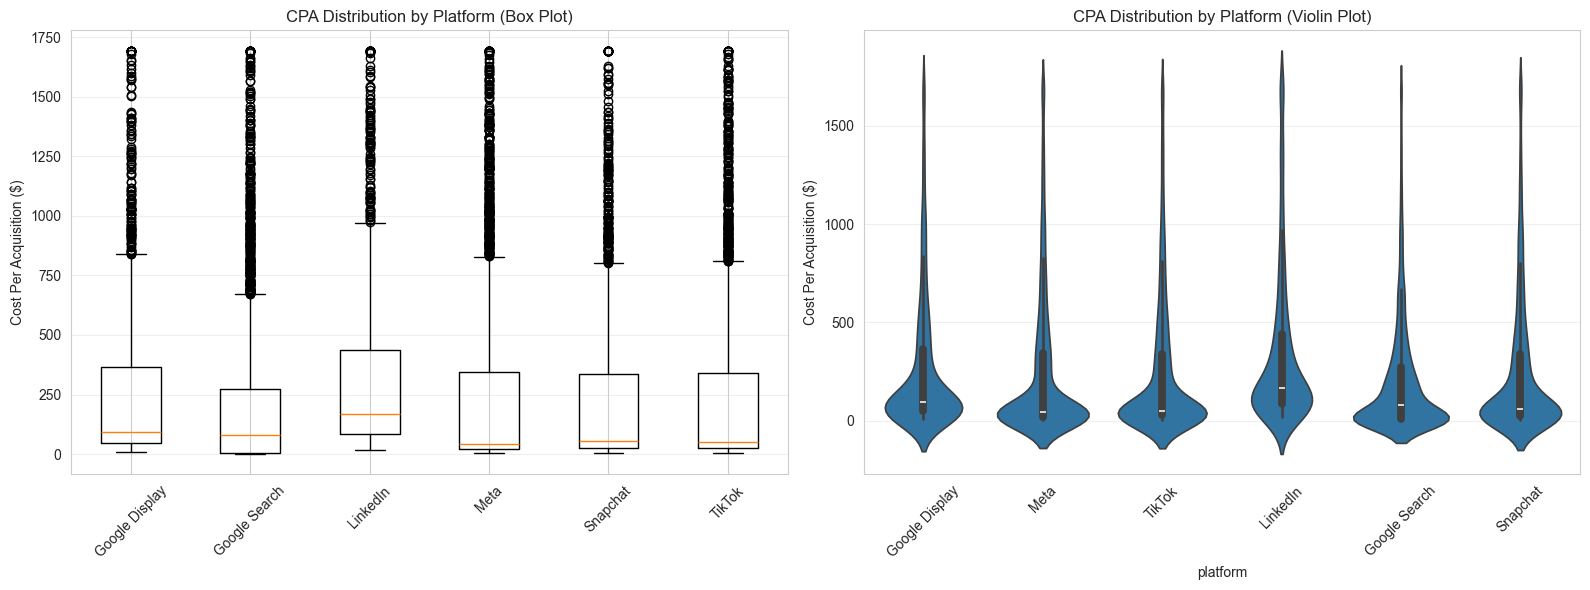

✓ Distribution visualization saved!


In [7]:
# Let's look at CPA distributions by platform
# Remove infinite/NaN values for visualization
df_clean_cpa = df[df['daily_CPA'].notna() & np.isfinite(df['daily_CPA'])].copy()

# Cap extreme outliers for better visualization (keep top 99%)
cpa_99th = df_clean_cpa['daily_CPA'].quantile(0.99)
df_clean_cpa['daily_CPA_capped'] = df_clean_cpa['daily_CPA'].clip(upper=cpa_99th)

print(f"CPA distribution stats (capped at 99th percentile: ${cpa_99th:.2f}):")
print(df_clean_cpa.groupby('platform')['daily_CPA_capped'].describe().round(2))

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot - shows median, quartiles, outliers
axes[0].boxplot([df_clean_cpa[df_clean_cpa['platform'] == p]['daily_CPA_capped'] 
                  for p in platform_summary['platform'].sort_values()],
                 labels=platform_summary['platform'].sort_values(),
                 showfliers=True)
axes[0].set_ylabel('Cost Per Acquisition ($)')
axes[0].set_title('CPA Distribution by Platform (Box Plot)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Violin plot - shows full distribution shape
import seaborn as sns
sns.violinplot(data=df_clean_cpa, x='platform', y='daily_CPA_capped', ax=axes[1])
axes[1].set_ylabel('Cost Per Acquisition ($)')
axes[1].set_title('CPA Distribution by Platform (Violin Plot)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/platform_cpa_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution visualization saved!")

In [8]:
# Quick sample size check
print("Sample sizes by platform (rows with valid CPA):")
print(df_clean_cpa['platform'].value_counts().sort_index())

Sample sizes by platform (rows with valid CPA):
platform
Google Display    1486
Google Search     4094
LinkedIn          1352
Meta              3638
Snapchat          2077
TikTok            2993
Name: count, dtype: int64


In [9]:
from itertools import combinations
from scipy.stats import ttest_ind

# Get all unique platform pairs (avoiding duplicates)
platforms = df_clean_cpa['platform'].unique()
platform_pairs = list(combinations(platforms, 2))

print(f"We'll run {len(platform_pairs)} pairwise comparisons")
print(f"Platform pairs: {platform_pairs}\n")

# Store results
t_test_results = []

# Perform t-test for each pair
for platform_a, platform_b in platform_pairs:
    # Get CPA data for each platform
    cpa_a = df_clean_cpa[df_clean_cpa['platform'] == platform_a]['daily_CPA_capped']
    cpa_b = df_clean_cpa[df_clean_cpa['platform'] == platform_b]['daily_CPA_capped']
    
    # Calculate means
    mean_a = cpa_a.mean()
    mean_b = cpa_b.mean()
    difference = mean_b - mean_a
    pct_diff = (difference / mean_a) * 100
    
    # Perform t-test
    t_stat, p_value = ttest_ind(cpa_a, cpa_b)
    
    # Calculate Cohen's d (effect size)
    pooled_std = np.sqrt((cpa_a.var() + cpa_b.var()) / 2)
    cohens_d = difference / pooled_std
    
    # Interpret effect size
    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    
    # Store results
    t_test_results.append({
        'Platform A': platform_a,
        'Platform B': platform_b,
        'Mean A': round(mean_a, 2),
        'Mean B': round(mean_b, 2),
        'Difference': round(difference, 2),
        'Pct Diff': round(pct_diff, 1),
        't-statistic': round(t_stat, 3),
        'p-value': p_value,
        'Cohens d': round(cohens_d, 3),
        'Effect Size': effect_size,
        'Significant (p<0.05)': p_value < 0.05
    })

# Convert to DataFrame
results_df = pd.DataFrame(t_test_results)

# Display results
print("T-Test Results for CPA Comparisons:")
print("="*80)
print(results_df.to_string(index=False))

# Summary
n_significant = results_df['Significant (p<0.05)'].sum()
print(f"\n{'='*80}")
print(f"Summary: {n_significant} out of {len(platform_pairs)} comparisons are significant at α=0.05")
print(f"Expected false positives (by chance): {len(platform_pairs) * 0.05:.1f}")

We'll run 15 pairwise comparisons
Platform pairs: [('Google Display', 'Meta'), ('Google Display', 'TikTok'), ('Google Display', 'LinkedIn'), ('Google Display', 'Google Search'), ('Google Display', 'Snapchat'), ('Meta', 'TikTok'), ('Meta', 'LinkedIn'), ('Meta', 'Google Search'), ('Meta', 'Snapchat'), ('TikTok', 'LinkedIn'), ('TikTok', 'Google Search'), ('TikTok', 'Snapchat'), ('LinkedIn', 'Google Search'), ('LinkedIn', 'Snapchat'), ('Google Search', 'Snapchat')]

T-Test Results for CPA Comparisons:
    Platform A    Platform B  Mean A  Mean B  Difference  Pct Diff  t-statistic      p-value  Cohens d Effect Size  Significant (p<0.05)
Google Display          Meta  266.72  244.10      -22.62      -8.5        2.003 4.527766e-02    -0.062  negligible                  True
Google Display        TikTok  266.72  246.34      -20.38      -7.6        1.783 7.465331e-02    -0.057  negligible                 False
Google Display      LinkedIn  266.72  343.79       77.08      28.9       -5.433 6.0225

In [11]:
from scipy.stats import fisher_exact

print("Fisher's Exact Test for Conversion Rates")
print("="*80)

# Aggregate conversion data by platform
conversion_summary = df.groupby('platform').agg({
    'conversions': 'sum',
    'clicks': 'sum'
}).reset_index()

# Calculate non-conversions
conversion_summary['non_conversions'] = conversion_summary['clicks'] - conversion_summary['conversions']
conversion_summary['conv_rate'] = conversion_summary['conversions'] / conversion_summary['clicks']

print("\nConversion summary by platform:")
print(conversion_summary)

# Store Fisher's test results
fisher_results = []

# Compare each pair
platforms = conversion_summary['platform'].unique()

for i, platform_a in enumerate(platforms):
    for platform_b in platforms[i+1:]:
        
        # Get data for platform A
        conv_a = conversion_summary[conversion_summary['platform'] == platform_a]['conversions'].values[0]
        total_a = conversion_summary[conversion_summary['platform'] == platform_a]['clicks'].values[0]
        non_conv_a = total_a - conv_a
        rate_a = conv_a / total_a
        
        # Get data for platform B
        conv_b = conversion_summary[conversion_summary['platform'] == platform_b]['conversions'].values[0]
        total_b = conversion_summary[conversion_summary['platform'] == platform_b]['clicks'].values[0]
        non_conv_b = total_b - conv_b
        rate_b = conv_b / total_b
        
        # Create 2x2 contingency table
        table = [[conv_a, non_conv_a],
                 [conv_b, non_conv_b]]
        
        # Fisher's exact test
        odds_ratio, p_val = fisher_exact(table, alternative='two-sided')
        
        # Calculate difference
        diff = rate_b - rate_a
        pct_diff = (diff / rate_a) * 100
        
        # Store results
        fisher_results.append({
            'Platform_A': platform_a,
            'Platform_B': platform_b,
            'Conv_A': conv_a,
            'Total_A': total_a,
            'Rate_A': round(rate_a, 4),
            'Conv_B': conv_b,
            'Total_B': total_b,
            'Rate_B': round(rate_b, 4),
            'Difference': round(diff, 4),
            'Pct_Diff': round(pct_diff, 1),
            'Odds_Ratio': round(odds_ratio, 3),
            'p_value': round(p_val, 6),
            'significant': p_val < 0.05
        })
        
        print(f"{platform_a:15} vs {platform_b:15} | p={p_val:.6f} | OR={odds_ratio:.3f} | Sig: {p_val < 0.05}")

# Convert to DataFrame
fisher_df = pd.DataFrame(fisher_results)

print(f"\n{'='*80}")
print(f"Summary: {fisher_df['significant'].sum()} out of {len(fisher_df)} comparisons significant (p<0.05)")
print(f"{'='*80}")

print("\nComplete Fisher's Exact Test Results:")
print(fisher_df.to_string(index=False))

Fisher's Exact Test for Conversion Rates

Conversion summary by platform:
         platform  conversions    clicks  non_conversions  conv_rate
0  Google Display         9109   1809793          1800684   0.005033
1   Google Search       216694  11515557         11298863   0.018818
2        LinkedIn         5588    685644           680056   0.008150
3            Meta        41978   4439765          4397787   0.009455
4        Snapchat        21148   3230264          3209116   0.006547
5          TikTok        28281   3936117          3907836   0.007185
Google Display  vs Google Search   | p=0.000000 | OR=0.264 | Sig: True
Google Display  vs LinkedIn        | p=0.000000 | OR=0.616 | Sig: True
Google Display  vs Meta            | p=0.000000 | OR=0.530 | Sig: True
Google Display  vs Snapchat        | p=0.000000 | OR=0.768 | Sig: True
Google Display  vs TikTok          | p=0.000000 | OR=0.699 | Sig: True
Google Search   vs LinkedIn        | p=0.000000 | OR=2.334 | Sig: True
Google Search   v

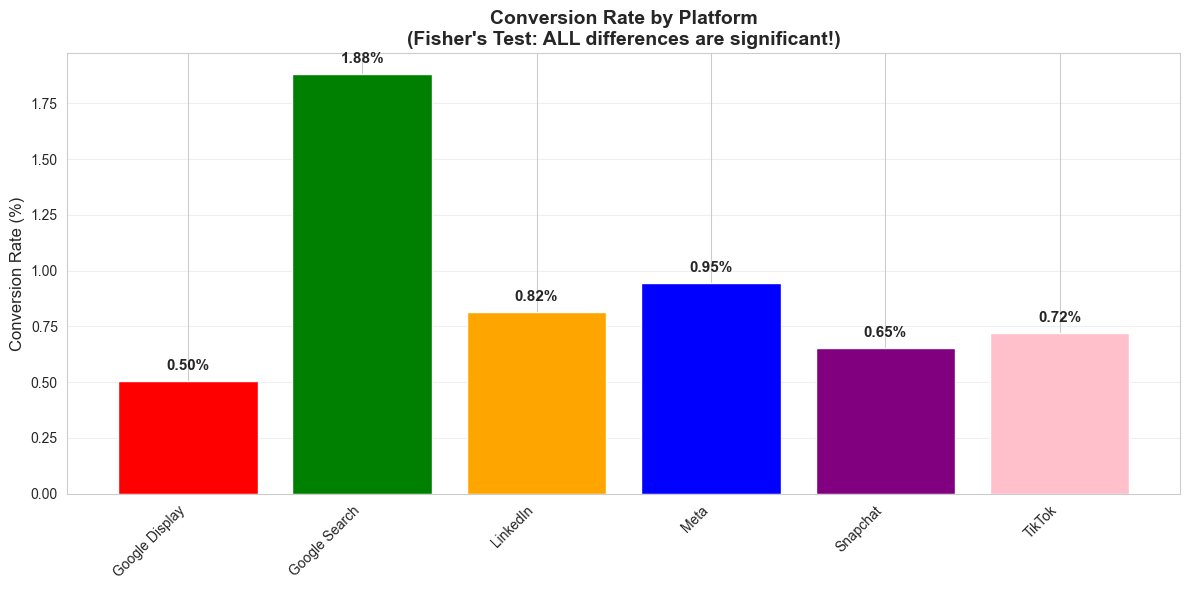

✓ Visualization saved!

Conversion Rate Comparison:
Google Display   0.50% █████
Google Search    1.88% ██████████████████
LinkedIn         0.82% ████████
Meta             0.95% █████████
Snapchat         0.65% ██████
TikTok           0.72% ███████


In [12]:
# Run this to visualize conversion rates
import matplotlib.pyplot as plt

# Get platform data
platforms = conversion_summary['platform'].values
conv_rates = (conversion_summary['conv_rate'] * 100).values  # Convert to percentage

# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(platforms, conv_rates, color=['red', 'green', 'orange', 'blue', 'purple', 'pink'])

# Add value labels on bars
for i, (platform, rate) in enumerate(zip(platforms, conv_rates)):
    plt.text(i, rate + 0.05, f'{rate:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.title('Conversion Rate by Platform\n(Fisher\'s Test: ALL differences are significant!)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/conversion_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved!")

# Create a comparison table
print("\nConversion Rate Comparison:")
print("="*60)
for i, row in conversion_summary.iterrows():
    platform = row['platform']
    rate = row['conv_rate'] * 100
    bar = '█' * int(rate * 10)  # Visual bar
    print(f"{platform:15} {rate:5.2f}% {bar}")

C:\Users\pbiai\AppData\Local\Temp\ipykernel_45384\3802518559.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pbiai\AppData\Local\Temp\ipykernel_45384\3802518559.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pbiai\AppData\Local\Temp\ipykernel_45384\3802518559.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('results/multiple_comparisons_explanation.png', dpi=300, bbox_inches='tight')
C:\Users\pbiai\AppData\Local\Temp\ipykernel_45384\3802518559.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig('results/multiple_comparisons_explanation.png', dpi=300, bbox_inches='tight')
c:\Users\pbiai\miniconda3\envs\ironhack_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure

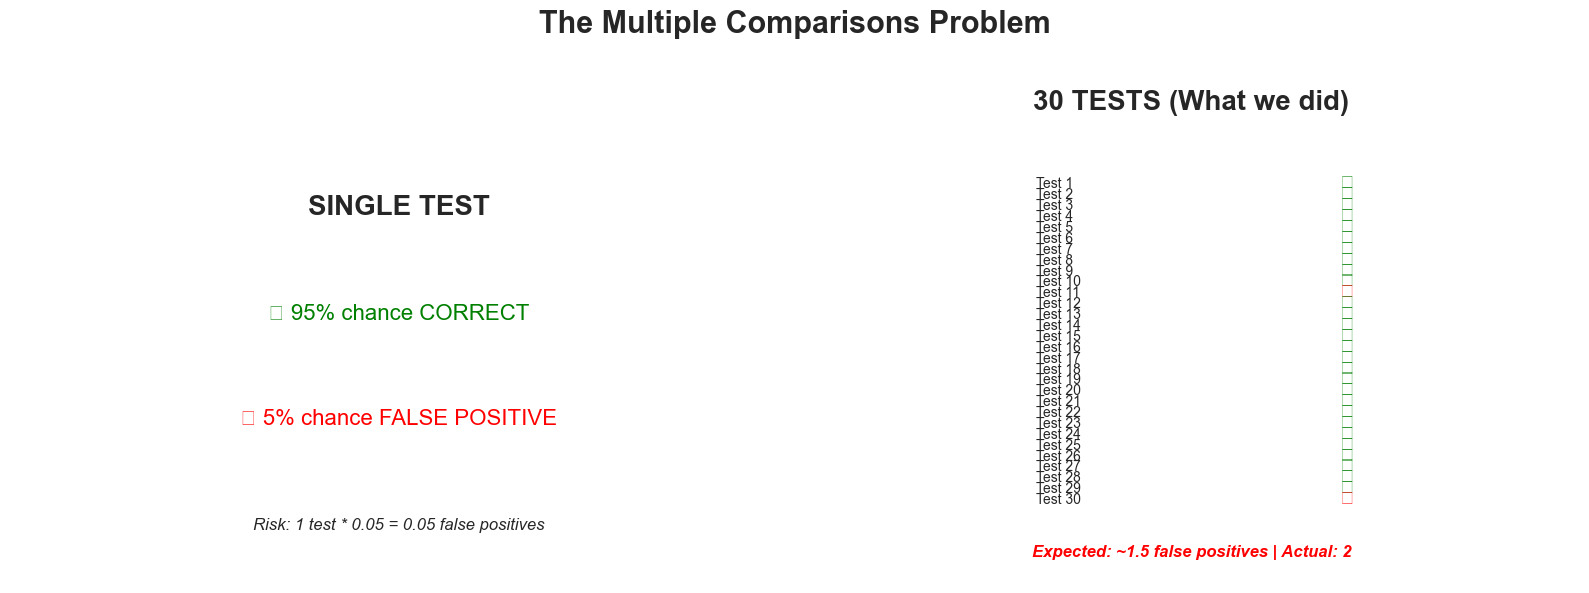

✓ Visualization created!


In [14]:
# Visualize the false positive problem
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Single Test
axes[0].text(0.5, 0.7, "SINGLE TEST", ha='center', fontsize=20, fontweight='bold')
axes[0].text(0.5, 0.5, "✅ 95% chance CORRECT", ha='center', fontsize=16, color='green')
axes[0].text(0.5, 0.3, "❌ 5% chance FALSE POSITIVE", ha='center', fontsize=16, color='red')
axes[0].text(0.5, 0.1, "Risk: 1 test * 0.05 = 0.05 false positives", ha='center', fontsize=12, style='italic')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].axis('off')

# RIGHT: 30 Tests
axes[1].text(0.5, 0.9, "30 TESTS (What we did)", ha='center', fontsize=20, fontweight='bold')

# Simulate 30 tests
np.random.seed(42)
test_results = np.random.random(30) > 0.05  # 95% True, 5% False

y_positions = np.linspace(0.75, 0.15, 30)
for i, (result, y) in enumerate(zip(test_results, y_positions)):
    color = 'green' if result else 'red'
    symbol = '✅' if result else '❌'
    axes[1].text(0.3, y, f"Test {i+1}", fontsize=10, ha='left')
    axes[1].text(0.7, y, symbol, fontsize=14, ha='center', color=color)

false_count = (~test_results).sum()
axes[1].text(0.5, 0.05, f"Expected: ~1.5 false positives | Actual: {false_count}", 
             ha='center', fontsize=12, style='italic', fontweight='bold', color='red')

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis('off')

plt.suptitle("The Multiple Comparisons Problem", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('results/multiple_comparisons_explanation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization created!")

In [16]:
# First convert to DataFrame if not already
t_test_results_df = pd.DataFrame(t_test_results)
fisher_results_df = pd.DataFrame(fisher_results)

# Now show the breakdown
print("YOUR ANALYSIS BREAKDOWN")
print("="*60)
print("\nCPA T-Tests (comparing cost per acquisition):")
print(f"  - Comparisons made: {len(t_test_results_df)}")
print(f"  - Significant (p<0.05): {t_test_results_df['Significant (p<0.05)'].sum()}")
print(f"  - Expected false positives: {len(t_test_results_df)} * 0.05 = {len(t_test_results_df) * 0.05:.2f}")
print(f"  - Interpretation: ~1 of these might be wrong!")

print("\nFisher's Exact Tests (comparing conversion rates):")
print(f"  - Comparisons made: {len(fisher_df)}")
print(f"  - Significant (p<0.05): {fisher_df['significant'].sum()}")
print(f"  - Expected false positives: {len(fisher_df)} * 0.05 = {len(fisher_df) * 0.05:.2f}")
print(f"  - Interpretation: ~1 of these might be wrong!")

print("\nCOMBINED:")
total_comparisons = len(t_test_results_df) + len(fisher_df)
total_significant = t_test_results_df['Significant (p<0.05)'].sum() + fisher_df['significant'].sum()
expected_false = total_comparisons * 0.05

print(f"  - TOTAL comparisons: {total_comparisons}")
print(f"  - TOTAL significant: {total_significant}")
print(f"  - Expected false positives: {total_comparisons} * 0.05 = {expected_false:.1f}")
print(f"  - Interpretation: ~{int(expected_false)}-{int(expected_false)+1} might be flukes!")

print("\n" + "="*60)
print("This is why we need CORRECTION!")
print("="*60)

YOUR ANALYSIS BREAKDOWN

CPA T-Tests (comparing cost per acquisition):
  - Comparisons made: 15
  - Significant (p<0.05): 10
  - Expected false positives: 15 * 0.05 = 0.75
  - Interpretation: ~1 of these might be wrong!

Fisher's Exact Tests (comparing conversion rates):
  - Comparisons made: 15
  - Significant (p<0.05): 15
  - Expected false positives: 15 * 0.05 = 0.75
  - Interpretation: ~1 of these might be wrong!

COMBINED:
  - TOTAL comparisons: 30
  - TOTAL significant: 25
  - Expected false positives: 30 * 0.05 = 1.5
  - Interpretation: ~1-2 might be flukes!

This is why we need CORRECTION!


In [18]:
# Show which comparisons were significant vs not
print("CPA T-TEST RESULTS BREAKDOWN")
print("="*80)

# Significant pairs
significant_pairs = t_test_results_df[t_test_results_df['Significant (p<0.05)'] == True]
print(f"\n✅ SIGNIFICANT PAIRS ({len(significant_pairs)}/15):")
print("These platforms have DIFFERENT CPAs:")
print("-"*80)
for _, row in significant_pairs.iterrows():
    print(f"{row['Platform A']:15} vs {row['Platform B']:15} | "
          f"${row['Mean A']:6.2f} vs ${row['Mean B']:6.2f} | "
          f"Diff: {row['Pct Diff']:+6.1f}% | "
          f"p={row['p-value']:.6f}")

# Not significant pairs  
not_significant = t_test_results_df[t_test_results_df['Significant (p<0.05)'] == False]
print(f"\n❌ NOT SIGNIFICANT PAIRS ({len(not_significant)}/15):")
print("These platforms have SIMILAR CPAs:")
print("-"*80)
for _, row in not_significant.iterrows():
    print(f"{row['Platform A']:15} vs {row['Platform B']:15} | "
          f"${row['Mean A']:6.2f} vs ${row['Mean B']:6.2f} | "
          f"Diff: {row['Pct Diff']:+6.1f}% | "
          f"p={row['p-value']:.6f}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("  - The 10 significant pairs show REAL differences in CPA")
print("  - The 5 non-significant pairs are statistically SIMILAR")
print("  - ~1 of the 10 significant might be a false positive")
print("="*80)


CPA T-TEST RESULTS BREAKDOWN

✅ SIGNIFICANT PAIRS (10/15):
These platforms have DIFFERENT CPAs:
--------------------------------------------------------------------------------
Google Display  vs Meta            | $266.72 vs $244.10 | Diff:   -8.5% | p=0.045278
Google Display  vs LinkedIn        | $266.72 vs $343.79 | Diff:  +28.9% | p=0.000000
Google Display  vs Google Search   | $266.72 vs $201.41 | Diff:  -24.5% | p=0.000000
Meta            vs LinkedIn        | $244.10 vs $343.79 | Diff:  +40.8% | p=0.000000
Meta            vs Google Search   | $244.10 vs $201.41 | Diff:  -17.5% | p=0.000000
TikTok          vs LinkedIn        | $246.34 vs $343.79 | Diff:  +39.6% | p=0.000000
TikTok          vs Google Search   | $246.34 vs $201.41 | Diff:  -18.2% | p=0.000000
LinkedIn        vs Google Search   | $343.79 vs $201.41 | Diff:  -41.4% | p=0.000000
LinkedIn        vs Snapchat        | $343.79 vs $246.15 | Diff:  -28.4% | p=0.000000
Google Search   vs Snapchat        | $201.41 vs $246.15 | 

In [19]:
from scipy.stats import false_discovery_control

print("MULTIPLE COMPARISONS CORRECTION")
print("="*80)

# Total comparisons
total_comparisons = len(t_test_results_df) + len(fisher_df)
print(f"\nTotal comparisons made: {total_comparisons}")
print(f"  - CPA t-tests: {len(t_test_results_df)}")
print(f"  - Fisher tests: {len(fisher_df)}")

expected_false = total_comparisons * 0.05
print(f"\nExpected false positives at α=0.05: {expected_false:.1f}")
print(f"⚠️  This means ~{int(expected_false)}-{int(expected_false)+1} significant results might be flukes!")

# ============================================================================
# BONFERRONI CORRECTION (Very Strict)
# ============================================================================
print("\n" + "="*80)
print("BONFERRONI CORRECTION (Very Conservative)")
print("="*80)

alpha = 0.05
bonferroni_alpha_cpa = alpha / len(t_test_results_df)
bonferroni_alpha_fisher = alpha / len(fisher_df)

print(f"\nOriginal α = {alpha}")
print(f"Bonferroni α for CPA = {alpha} / {len(t_test_results_df)} = {bonferroni_alpha_cpa:.6f}")
print(f"Bonferroni α for Fisher = {alpha} / {len(fisher_df)} = {bonferroni_alpha_fisher:.6f}")

# Apply Bonferroni to CPA
t_test_results_df['sig_bonferroni'] = t_test_results_df['p-value'] < bonferroni_alpha_cpa
n_sig_bonf_cpa = t_test_results_df['sig_bonferroni'].sum()

# Apply Bonferroni to Fisher
fisher_df['sig_bonferroni'] = fisher_df['p_value'] < bonferroni_alpha_fisher
n_sig_bonf_fisher = fisher_df['sig_bonferroni'].sum()

print(f"\nResults AFTER Bonferroni:")
print(f"  CPA: {n_sig_bonf_cpa}/{len(t_test_results_df)} still significant")
print(f"  Fisher: {n_sig_bonf_fisher}/{len(fisher_df)} still significant")

# ============================================================================
# FDR CORRECTION (Less Strict, More Practical)
# ============================================================================
print("\n" + "="*80)
print("FDR (BENJAMINI-HOCHBERG) CORRECTION (Balanced)")
print("="*80)

# Apply FDR to CPA
t_test_results_df['p_value_fdr'] = false_discovery_control(
    t_test_results_df['p-value'].values, 
    method='bh'
)
t_test_results_df['sig_fdr'] = t_test_results_df['p_value_fdr'] < alpha
n_sig_fdr_cpa = t_test_results_df['sig_fdr'].sum()

# Apply FDR to Fisher
fisher_df['p_value_fdr'] = false_discovery_control(
    fisher_df['p_value'].values,
    method='bh'
)
fisher_df['sig_fdr'] = fisher_df['p_value_fdr'] < alpha
n_sig_fdr_fisher = fisher_df['sig_fdr'].sum()

print(f"\nResults AFTER FDR:")
print(f"  CPA: {n_sig_fdr_cpa}/{len(t_test_results_df)} still significant")
print(f"  Fisher: {n_sig_fdr_fisher}/{len(fisher_df)} still significant")

# ============================================================================
# COMPARISON TABLE
# ============================================================================
print("\n" + "="*80)
print("CORRECTION METHOD COMPARISON")
print("="*80)

comparison_data = {
    'Method': ['Uncorrected', 'Bonferroni', 'FDR (BH)'],
    'CPA Significant': [
        t_test_results_df['Significant (p<0.05)'].sum(),
        n_sig_bonf_cpa,
        n_sig_fdr_cpa
    ],
    'Fisher Significant': [
        fisher_df['significant'].sum(),
        n_sig_bonf_fisher,
        n_sig_fdr_fisher
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Total'] = comparison_df['CPA Significant'] + comparison_df['Fisher Significant']

print("\n", comparison_df.to_string(index=False))

# Show survivors
print("\n" + "="*80)
print("CPA COMPARISONS AFTER FDR CORRECTION (The Real Differences):")
print("="*80)
survivors_cpa = t_test_results_df[t_test_results_df['sig_fdr']]
print(survivors_cpa[['Platform A', 'Platform B', 'Mean A', 'Mean B', 'Pct Diff', 'p-value', 'Cohens d']].to_string(index=False))

print("\n" + "="*80)
print("FISHER COMPARISONS AFTER FDR CORRECTION (The Real Differences):")
print("="*80)
survivors_fisher = fisher_df[fisher_df['sig_fdr']]
print(survivors_fisher[['Platform_A', 'Platform_B', 'Rate_A', 'Rate_B', 'Pct_Diff', 'p_value']].to_string(index=False))

print("\n" + "="*80)
print("✅ CORRECTION COMPLETE!")
print("="*80)

MULTIPLE COMPARISONS CORRECTION

Total comparisons made: 30
  - CPA t-tests: 15
  - Fisher tests: 15

Expected false positives at α=0.05: 1.5
⚠️  This means ~1-2 significant results might be flukes!

BONFERRONI CORRECTION (Very Conservative)

Original α = 0.05
Bonferroni α for CPA = 0.05 / 15 = 0.003333
Bonferroni α for Fisher = 0.05 / 15 = 0.003333

Results AFTER Bonferroni:
  CPA: 9/15 still significant
  Fisher: 15/15 still significant

FDR (BENJAMINI-HOCHBERG) CORRECTION (Balanced)

Results AFTER FDR:
  CPA: 9/15 still significant
  Fisher: 15/15 still significant

CORRECTION METHOD COMPARISON

      Method  CPA Significant  Fisher Significant  Total
Uncorrected               10                  15     25
 Bonferroni                9                  15     24
   FDR (BH)                9                  15     24

CPA COMPARISONS AFTER FDR CORRECTION (The Real Differences):
    Platform A    Platform B  Mean A  Mean B  Pct Diff      p-value  Cohens d
Google Display      LinkedIn 

In [21]:
# Show what data we used for ONE comparison
print("EXAMPLE: Meta vs Google Search Comparison")
print("="*80)

# CPA T-Test data
meta_cpa_data = df_clean_cpa[df_clean_cpa['platform'] == 'Meta']['daily_CPA_capped']
gsearch_cpa_data = df_clean_cpa[df_clean_cpa['platform'] == 'Google Search']['daily_CPA_capped']

print("\nCPA T-TEST:")
print(f"  Meta: {len(meta_cpa_data)} daily CPA observations")
print(f"    - Mean CPA: ${meta_cpa_data.mean():.2f}")
print(f"    - First 10 CPAs: {list(meta_cpa_data.head(10).values)}")

print(f"\n  Google Search: {len(gsearch_cpa_data)} daily CPA observations")
print(f"    - Mean CPA: ${gsearch_cpa_data.mean():.2f}")
print(f"    - First 10 CPAs: {list(gsearch_cpa_data.head(10).values)}")

# Fisher's test data
meta_summary = conversion_summary[conversion_summary['platform'] == 'Meta']
gsearch_summary = conversion_summary[conversion_summary['platform'] == 'Google Search']

print("\n" + "="*80)
print("FISHER'S EXACT TEST:")
print(f"\n  Meta:")
print(f"    - Total clicks: {meta_summary['clicks'].values[0]:,}")
print(f"    - Conversions: {meta_summary['conversions'].values[0]:,}")
print(f"    - Conversion rate: {meta_summary['conv_rate'].values[0]:.4f}")

print(f"\n  Google Search:")
print(f"    - Total clicks: {gsearch_summary['clicks'].values[0]:,}")
print(f"    - Conversions: {gsearch_summary['conversions'].values[0]:,}")
print(f"    - Conversion rate: {gsearch_summary['conv_rate'].values[0]:.4f}")

print("\n" + "="*80)
print("KEY POINT:")
print("  - CPA test used THOUSANDS of daily observations per platform")
print("  - Fisher test used MILLIONS of clicks per platform")
print("  - This is just ONE of the 15 comparisons!")
print("  - We repeated this for all 15 platform pairs")

EXAMPLE: Meta vs Google Search Comparison

CPA T-TEST:
  Meta: 3638 daily CPA observations
    - Mean CPA: $244.10
    - First 10 CPAs: [np.float64(26.99), np.float64(8.13), np.float64(403.55), np.float64(891.975), np.float64(49.73470588235294), np.float64(65.415), np.float64(29.595), np.float64(865.31), np.float64(251.49), np.float64(376.74666666666667)]

  Google Search: 4094 daily CPA observations
    - Mean CPA: $201.41
    - First 10 CPAs: [np.float64(288.5), np.float64(202.4), np.float64(2.996086956521739), np.float64(2.743009009009009), np.float64(14.553999999999998), np.float64(479.435), np.float64(7.3933333333333335), np.float64(631.04), np.float64(356.485), np.float64(3.732921348314607)]

FISHER'S EXACT TEST:

  Meta:
    - Total clicks: 4,439,765
    - Conversions: 41,978
    - Conversion rate: 0.0095

  Google Search:
    - Total clicks: 11,515,557
    - Conversions: 216,694
    - Conversion rate: 0.0188

KEY POINT:
  - CPA test used THOUSANDS of daily observations per plat

In [22]:
import numpy as np
from scipy.stats import ttest_ind

print("POWER ANALYSIS - PART A: Empirical Power Calculation")
print("="*80)
print("\nThis simulates: 'If we repeated our study, would we get the same results?'\n")

# We'll calculate power for each of our 15 platform pairs
# Using the actual observed effect sizes and sample sizes

def calculate_power(mean1, std1, n1, mean2, std2, n2, alpha=0.05, n_simulations=1000):
    """
    Calculate statistical power through simulation
    
    mean1, std1, n1: stats for platform 1
    mean2, std2, n2: stats for platform 2
    alpha: significance level
    n_simulations: number of simulated experiments
    """
    significant_count = 0
    
    for _ in range(n_simulations):
        # Simulate data from both platforms
        sample1 = np.random.normal(mean1, std1, n1)
        sample2 = np.random.normal(mean2, std2, n2)
        
        # Run t-test
        t_stat, p_val = ttest_ind(sample1, sample2)
        
        # Count if significant
        if p_val < alpha:
            significant_count += 1
    
    power = significant_count / n_simulations
    return power

# Calculate power for each comparison
print("Calculating power for each platform pair...")
print("(This takes ~2 minutes - simulating 1,000 experiments per pair)\n")

power_results = []

for idx, row in t_test_results_df.iterrows():
    platform_a = row['Platform A']
    platform_b = row['Platform B']
    
    # Get data for both platforms
    data_a = df_clean_cpa[df_clean_cpa['platform'] == platform_a]['daily_CPA_capped']
    data_b = df_clean_cpa[df_clean_cpa['platform'] == platform_b]['daily_CPA_capped']
    
    # Calculate power
    power = calculate_power(
        mean1=data_a.mean(),
        std1=data_a.std(),
        n1=len(data_a),
        mean2=data_b.mean(),
        std2=data_b.std(),
        n2=len(data_b),
        n_simulations=1000
    )
    
    power_results.append({
        'Platform_A': platform_a,
        'Platform_B': platform_b,
        'n_A': len(data_a),
        'n_B': len(data_b),
        'Effect_Size': abs(row['Cohens d']),
        'Was_Significant': row['Significant (p<0.05)'],
        'Power': round(power, 3)
    })
    
    status = "✅" if power >= 0.8 else "⚠️" if power >= 0.5 else "🔴"
    print(f"{status} {platform_a:15} vs {platform_b:15} | Power: {power:.3f} | n={len(data_a):4}/{len(data_b):4}")

# Convert to DataFrame
power_df = pd.DataFrame(power_results)

print("\n" + "="*80)
print("POWER ANALYSIS SUMMARY")
print("="*80)

# Categorize by power level
high_power = power_df[power_df['Power'] >= 0.8]
medium_power = power_df[(power_df['Power'] >= 0.5) & (power_df['Power'] < 0.8)]
low_power = power_df[power_df['Power'] < 0.5]

print(f"\n✅ HIGH POWER (≥80%): {len(high_power)}/15 comparisons")
print(f"⚠️  MEDIUM POWER (50-80%): {len(medium_power)}/15 comparisons")
print(f"🔴 LOW POWER (<50%): {len(low_power)}/15 comparisons")

# Show low power comparisons (risk of false negatives)
if len(low_power) > 0:
    print(f"\n🔴 LOW POWER COMPARISONS (High risk of missing real differences):")
    print("-"*80)
    print(low_power[['Platform_A', 'Platform_B', 'Power', 'Was_Significant', 'n_A', 'n_B']].to_string(index=False))
else:
    print("\n✅ No low-power comparisons - all tests are reliable!")

# Check for potential false negatives
print("\n" + "="*80)
print("FALSE NEGATIVE RISK ASSESSMENT")
print("="*80)

not_sig_comparisons = power_df[power_df['Was_Significant'] == False]
print(f"\nWe found {len(not_sig_comparisons)} NON-significant comparisons.")
print("Are these truly similar, or did we miss real differences?\n")

for _, row in not_sig_comparisons.iterrows():
    power = row['Power']
    if power < 0.5:
        risk = "🔴 HIGH RISK - may have missed a real difference!"
    elif power < 0.8:
        risk = "⚠️  MEDIUM RISK - borderline"
    else:
        risk = "✅ LOW RISK - probably truly similar"
    
    print(f"{row['Platform_A']:15} vs {row['Platform_B']:15} | Power: {power:.3f} | {risk}")

print("\n" + "="*80)

POWER ANALYSIS - PART A: Empirical Power Calculation

This simulates: 'If we repeated our study, would we get the same results?'

Calculating power for each platform pair...
(This takes ~2 minutes - simulating 1,000 experiments per pair)

⚠️ Google Display  vs Meta            | Power: 0.510 | n=1486/3638
🔴 Google Display  vs TikTok          | Power: 0.441 | n=1486/2993
✅ Google Display  vs LinkedIn        | Power: 1.000 | n=1486/1352
✅ Google Display  vs Google Search   | Power: 1.000 | n=1486/4094
🔴 Google Display  vs Snapchat        | Power: 0.370 | n=1486/2077
🔴 Meta            vs TikTok          | Power: 0.049 | n=3638/2993
✅ Meta            vs LinkedIn        | Power: 1.000 | n=3638/1352
✅ Meta            vs Google Search   | Power: 0.999 | n=3638/4094
🔴 Meta            vs Snapchat        | Power: 0.052 | n=3638/2077
✅ TikTok          vs LinkedIn        | Power: 1.000 | n=2993/1352
✅ TikTok          vs Google Search   | Power: 1.000 | n=2993/4094
🔴 TikTok          vs Snapchat     

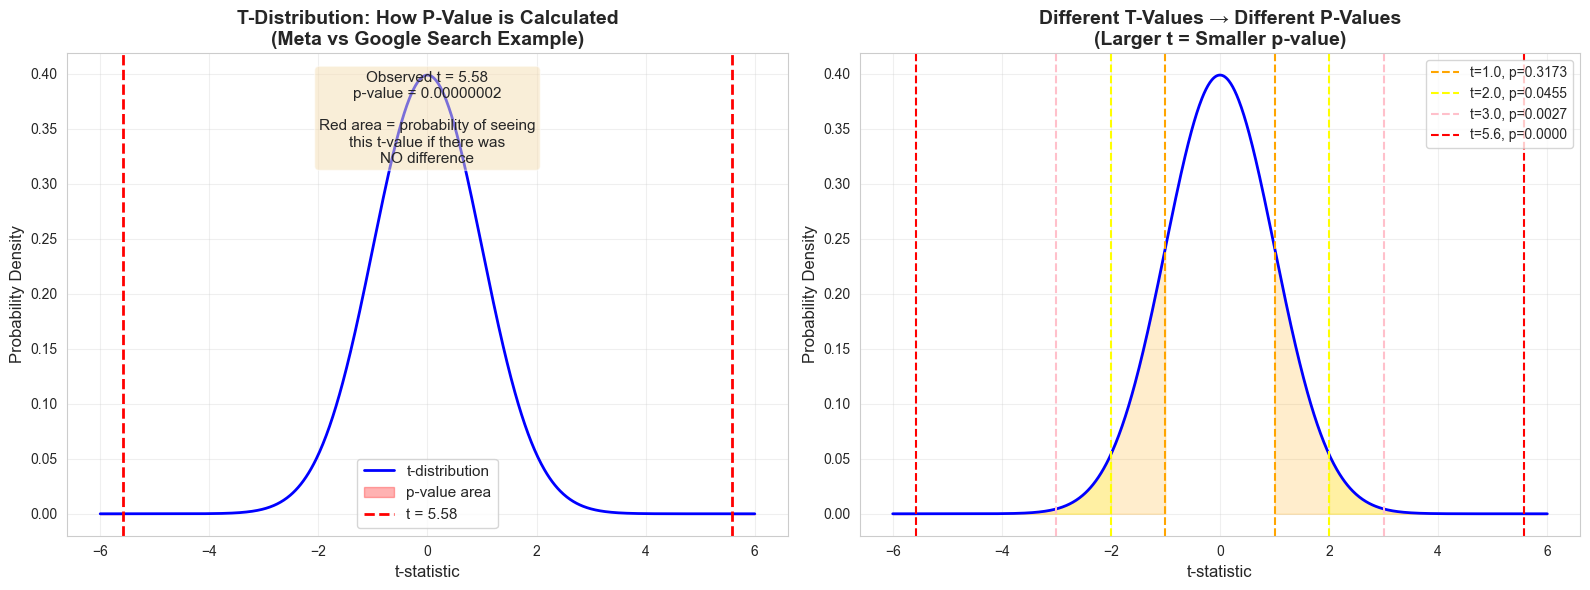

✓ T-distribution visualization created!

KEY POINTS:
1. The bell curve = t-distribution (theoretical)
2. Vertical line = our observed t-statistic
3. RED shaded area = p-value
4. Larger t-value → smaller shaded area → smaller p-value
5. p-value = 'How extreme is our result if no real difference?'


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Create a visualization of the t-distribution and p-value
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: T-Distribution with shaded p-value area =====
ax1 = axes[0]

# Example: Meta vs Google Search t-statistic
t_observed = 5.58  # Our calculated t-value
df = 3638 + 4094 - 2  # degrees of freedom

# Generate t-distribution curve
x = np.linspace(-6, 6, 1000)
y = stats.t.pdf(x, df)

# Plot the curve
ax1.plot(x, y, 'b-', linewidth=2, label='t-distribution')
ax1.fill_between(x, y, where=(x >= t_observed), alpha=0.3, color='red', label='p-value area')
ax1.fill_between(x, y, where=(x <= -t_observed), alpha=0.3, color='red')

# Mark the observed t-value
ax1.axvline(t_observed, color='red', linestyle='--', linewidth=2, label=f't = {t_observed}')
ax1.axvline(-t_observed, color='red', linestyle='--', linewidth=2)

# Add labels
ax1.set_xlabel('t-statistic', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('T-Distribution: How P-Value is Calculated\n(Meta vs Google Search Example)', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Calculate and display p-value
p_value = 2 * (1 - stats.t.cdf(t_observed, df))
ax1.text(0, max(y)*0.8, f'Observed t = {t_observed}\np-value = {p_value:.8f}\n\n' + 
         'Red area = probability of seeing\nthis t-value if there was\nNO difference', 
         ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ===== RIGHT PLOT: Different t-values and their p-values =====
ax2 = axes[1]

# Plot the curve again
ax2.plot(x, y, 'b-', linewidth=2)

# Show multiple t-values
t_values = [1.0, 2.0, 3.0, 5.58]
colors = ['orange', 'yellow', 'pink', 'red']

for t_val, color in zip(t_values, colors):
    p_val = 2 * (1 - stats.t.cdf(t_val, df))
    ax2.fill_between(x, y, where=(x >= t_val), alpha=0.2, color=color)
    ax2.fill_between(x, y, where=(x <= -t_val), alpha=0.2, color=color)
    ax2.axvline(t_val, color=color, linestyle='--', linewidth=1.5, 
                label=f't={t_val:.1f}, p={p_val:.4f}')
    ax2.axvline(-t_val, color=color, linestyle='--', linewidth=1.5)

ax2.set_xlabel('t-statistic', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('Different T-Values → Different P-Values\n(Larger t = Smaller p-value)', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/t_distribution_explained.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ T-distribution visualization created!")
print("\nKEY POINTS:")
print("=" * 60)
print("1. The bell curve = t-distribution (theoretical)")
print("2. Vertical line = our observed t-statistic")
print("3. RED shaded area = p-value")
print("4. Larger t-value → smaller shaded area → smaller p-value")
print("5. p-value = 'How extreme is our result if no real difference?'")

In [24]:
import numpy as np
from scipy.stats import ttest_ind

print("POWER ANALYSIS - Empirical Power Calculation")
print("="*80)
print("\nThis simulates: 'If we repeated our study, would we get the same results?'\n")

# Function to calculate power through simulation
def calculate_power(mean1, std1, n1, mean2, std2, n2, alpha=0.05, n_simulations=1000):
    """
    Calculate statistical power through simulation
    
    mean1, std1, n1: stats for platform 1
    mean2, std2, n2: stats for platform 2
    alpha: significance level
    n_simulations: number of simulated experiments
    """
    significant_count = 0
    
    for _ in range(n_simulations):
        # Simulate data from both platforms
        sample1 = np.random.normal(mean1, std1, n1)
        sample2 = np.random.normal(mean2, std2, n2)
        
        # Run t-test
        t_stat, p_val = ttest_ind(sample1, sample2)
        
        # Count if significant
        if p_val < alpha:
            significant_count += 1
    
    power = significant_count / n_simulations
    return power

# Calculate power for each comparison
print("Calculating power for each platform pair...")
print("(This takes ~2 minutes - simulating 1,000 experiments per pair)\n")

power_results = []

for idx, row in t_test_results_df.iterrows():
    platform_a = row['Platform A']
    platform_b = row['Platform B']
    
    # Get data for both platforms
    data_a = df_clean_cpa[df_clean_cpa['platform'] == platform_a]['daily_CPA_capped']
    data_b = df_clean_cpa[df_clean_cpa['platform'] == platform_b]['daily_CPA_capped']
    
    # Calculate power
    power = calculate_power(
        mean1=data_a.mean(),
        std1=data_a.std(),
        n1=len(data_a),
        mean2=data_b.mean(),
        std2=data_b.std(),
        n2=len(data_b),
        n_simulations=1000
    )
    
    power_results.append({
        'Platform_A': platform_a,
        'Platform_B': platform_b,
        'n_A': len(data_a),
        'n_B': len(data_b),
        'Effect_Size': abs(row['Cohens d']),
        'Was_Significant': row['Significant (p<0.05)'],
        'Power': round(power, 3)
    })
    
    status = "✅" if power >= 0.8 else "⚠️" if power >= 0.5 else "🔴"
    print(f"{status} {platform_a:15} vs {platform_b:15} | Power: {power:.3f} | n={len(data_a):4}/{len(data_b):4}")

# Convert to DataFrame
power_df = pd.DataFrame(power_results)

print("\n" + "="*80)
print("POWER ANALYSIS SUMMARY")
print("="*80)

# Categorize by power level
high_power = power_df[power_df['Power'] >= 0.8]
medium_power = power_df[(power_df['Power'] >= 0.5) & (power_df['Power'] < 0.8)]
low_power = power_df[power_df['Power'] < 0.5]

print(f"\n✅ HIGH POWER (≥80%): {len(high_power)}/15 comparisons")
print(f"⚠️  MEDIUM POWER (50-80%): {len(medium_power)}/15 comparisons")
print(f"🔴 LOW POWER (<50%): {len(low_power)}/15 comparisons")

# Show low power comparisons (risk of false negatives)
if len(low_power) > 0:
    print(f"\n🔴 LOW POWER COMPARISONS (High risk of missing real differences):")
    print("-"*80)
    print(low_power[['Platform_A', 'Platform_B', 'Power', 'Was_Significant', 'n_A', 'n_B']].to_string(index=False))
else:
    print("\n✅ No low-power comparisons - all tests are reliable!")

# Check for potential false negatives
print("\n" + "="*80)
print("FALSE NEGATIVE RISK ASSESSMENT")
print("="*80)

not_sig_comparisons = power_df[power_df['Was_Significant'] == False]
print(f"\nWe found {len(not_sig_comparisons)} NON-significant comparisons.")
print("Are these truly similar, or did we miss real differences?\n")

if len(not_sig_comparisons) > 0:
    for _, row in not_sig_comparisons.iterrows():
        power = row['Power']
        if power < 0.5:
            risk = "🔴 HIGH RISK - may have missed a real difference!"
        elif power < 0.8:
            risk = "⚠️  MEDIUM RISK - borderline"
        else:
            risk = "✅ LOW RISK - probably truly similar"
        
        print(f"{row['Platform_A']:15} vs {row['Platform_B']:15} | Power: {power:.3f} | {risk}")
else:
    print("All comparisons were significant - no false negative risk to assess.")

print("\n" + "="*80)
print("✅ POWER ANALYSIS COMPLETE!")
print("="*80)

POWER ANALYSIS - Empirical Power Calculation

This simulates: 'If we repeated our study, would we get the same results?'

Calculating power for each platform pair...
(This takes ~2 minutes - simulating 1,000 experiments per pair)

⚠️ Google Display  vs Meta            | Power: 0.505 | n=1486/3638
🔴 Google Display  vs TikTok          | Power: 0.453 | n=1486/2993
✅ Google Display  vs LinkedIn        | Power: 0.999 | n=1486/1352
✅ Google Display  vs Google Search   | Power: 1.000 | n=1486/4094
🔴 Google Display  vs Snapchat        | Power: 0.417 | n=1486/2077
🔴 Meta            vs TikTok          | Power: 0.055 | n=3638/2993
✅ Meta            vs LinkedIn        | Power: 1.000 | n=3638/1352
✅ Meta            vs Google Search   | Power: 0.999 | n=3638/4094
🔴 Meta            vs Snapchat        | Power: 0.054 | n=3638/2077
✅ TikTok          vs LinkedIn        | Power: 1.000 | n=2993/1352
✅ TikTok          vs Google Search   | Power: 0.999 | n=2993/4094
🔴 TikTok          vs Snapchat        | Pow

META CPA DISTRIBUTION:
  Mean: $244.10
  Std Dev: $371.11
  Min: $4.15
  Max: $1694.11
  Sample CPAs: [np.float64(26.99), np.float64(8.13), np.float64(403.55), np.float64(891.975), np.float64(49.73470588235294), np.float64(65.415), np.float64(29.595), np.float64(865.31), np.float64(251.49), np.float64(376.74666666666667), np.float64(13.541891891891892), np.float64(11.416666666666666), np.float64(338.195), np.float64(22.42), np.float64(32.372580645161285), np.float64(22.064117647058822), np.float64(28.401999999999997), np.float64(12.893333333333333), np.float64(30.51), np.float64(37.244375)]

TIKTOK CPA DISTRIBUTION:
  Mean: $246.34
  Std Dev: $362.11
  Min: $5.05
  Max: $1694.11
  Sample CPAs: [np.float64(34.451), np.float64(348.13), np.float64(533.99), np.float64(28.137916666666666), np.float64(284.095), np.float64(418.32666666666665), np.float64(43.53181818181818), np.float64(38.33166666666667), np.float64(24.28), np.float64(1591.85), np.float64(26.0508), np.float64(37.34900000000000

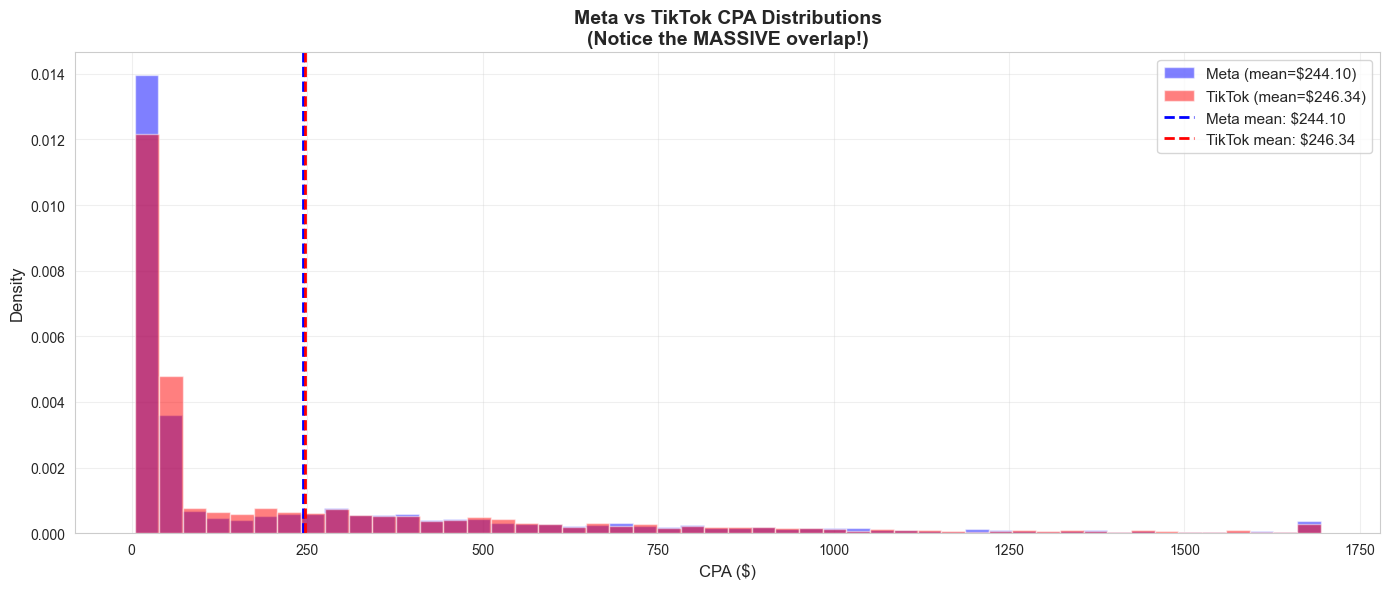


✓ Visualization created!


In [25]:
# Let's look at the ACTUAL CPA distributions
meta_cpas = df_clean_cpa[df_clean_cpa['platform'] == 'Meta']['daily_CPA_capped']
tiktok_cpas = df_clean_cpa[df_clean_cpa['platform'] == 'TikTok']['daily_CPA_capped']

print("META CPA DISTRIBUTION:")
print(f"  Mean: ${meta_cpas.mean():.2f}")
print(f"  Std Dev: ${meta_cpas.std():.2f}")
print(f"  Min: ${meta_cpas.min():.2f}")
print(f"  Max: ${meta_cpas.max():.2f}")
print(f"  Sample CPAs: {list(meta_cpas.head(20).values)}")

print("\nTIKTOK CPA DISTRIBUTION:")
print(f"  Mean: ${tiktok_cpas.mean():.2f}")
print(f"  Std Dev: ${tiktok_cpas.std():.2f}")
print(f"  Min: ${tiktok_cpas.min():.2f}")
print(f"  Max: ${tiktok_cpas.max():.2f}")
print(f"  Sample CPAs: {list(tiktok_cpas.head(20).values)}")

print("\nCOMPARISON:")
print(f"  Difference in means: ${abs(meta_cpas.mean() - tiktok_cpas.mean()):.2f}")
print(f"  Average std dev: ${(meta_cpas.std() + tiktok_cpas.std())/2:.2f}")
print(f"  Signal-to-noise ratio: {abs(meta_cpas.mean() - tiktok_cpas.mean()) / ((meta_cpas.std() + tiktok_cpas.std())/2):.4f}")

# Visualize the overlap
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.hist(meta_cpas, bins=50, alpha=0.5, label=f'Meta (mean=${meta_cpas.mean():.2f})', color='blue', density=True)
plt.hist(tiktok_cpas, bins=50, alpha=0.5, label=f'TikTok (mean=${tiktok_cpas.mean():.2f})', color='red', density=True)

plt.axvline(meta_cpas.mean(), color='blue', linestyle='--', linewidth=2, label=f'Meta mean: ${meta_cpas.mean():.2f}')
plt.axvline(tiktok_cpas.mean(), color='red', linestyle='--', linewidth=2, label=f'TikTok mean: ${tiktok_cpas.mean():.2f}')

plt.xlabel('CPA ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Meta vs TikTok CPA Distributions\n(Notice the MASSIVE overlap!)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/meta_vs_tiktok_overlap.png', dpi=300)
plt.show()

print("\n✓ Visualization created!")

META vs TIKTOK: MEAN vs MEDIAN COMPARISON

META:
  Mean:   $244.10
  Median: $42.42
  Std Dev: $371.11

TIKTOK:
  Mean:   $246.34
  Median: $51.19
  Std Dev: $362.11

DIFFERENCE:
  Mean difference:   $2.24
  Median difference: $8.77

ALL PLATFORMS: MEAN vs MEDIAN

       Platform   Mean  Median  Difference (Mean-Median)  Std Dev
          Meta 244.10   42.42                    201.68   371.11
        TikTok 246.34   51.19                    195.15   362.11
      Snapchat 246.15   56.65                    189.50   356.50
 Google Search 201.41   81.60                    119.81   301.46
Google Display 266.72   93.61                    173.11   356.35
      LinkedIn 343.79  167.40                    176.39   399.43


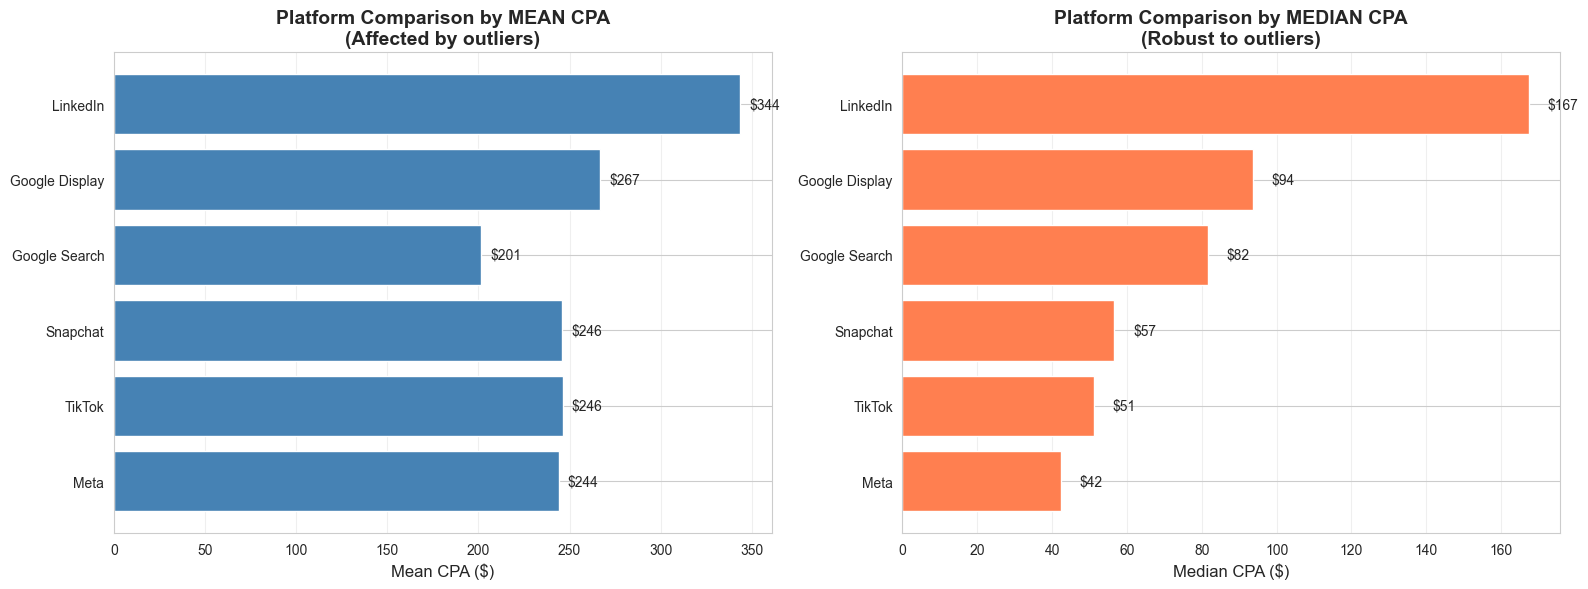


Visualization created!


In [28]:
# Compare mean vs median for Meta and TikTok
print("META vs TIKTOK: MEAN vs MEDIAN COMPARISON")
print("="*80)

meta_cpas = df_clean_cpa[df_clean_cpa['platform'] == 'Meta']['daily_CPA_capped']
tiktok_cpas = df_clean_cpa[df_clean_cpa['platform'] == 'TikTok']['daily_CPA_capped']

print("\nMETA:")
print(f"  Mean:   ${meta_cpas.mean():.2f}")
print(f"  Median: ${meta_cpas.median():.2f}")
print(f"  Std Dev: ${meta_cpas.std():.2f}")

print("\nTIKTOK:")
print(f"  Mean:   ${tiktok_cpas.mean():.2f}")
print(f"  Median: ${tiktok_cpas.median():.2f}")
print(f"  Std Dev: ${tiktok_cpas.std():.2f}")

print("\nDIFFERENCE:")
print(f"  Mean difference:   ${abs(meta_cpas.mean() - tiktok_cpas.mean()):.2f}")
print(f"  Median difference: ${abs(meta_cpas.median() - tiktok_cpas.median()):.2f}")

# Compare ALL platforms
print("\n" + "="*80)
print("ALL PLATFORMS: MEAN vs MEDIAN")
print("="*80)

comparison_data = []

for platform in df_clean_cpa['platform'].unique():
    platform_data = df_clean_cpa[df_clean_cpa['platform'] == platform]['daily_CPA_capped']
    
    comparison_data.append({
        'Platform': platform,
        'Mean': round(platform_data.mean(), 2),
        'Median': round(platform_data.median(), 2),
        'Difference (Mean-Median)': round(platform_data.mean() - platform_data.median(), 2),
        'Std Dev': round(platform_data.std(), 2)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Median')

print("\n", comparison_df.to_string(index=False))

# Visualize mean vs median
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Mean comparison
ax1 = axes[0]
platforms = comparison_df['Platform']
means = comparison_df['Mean']
ax1.barh(platforms, means, color='steelblue')
ax1.set_xlabel('Mean CPA ($)', fontsize=12)
ax1.set_title('Platform Comparison by MEAN CPA\n(Affected by outliers)', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(means):
    ax1.text(v + 5, i, f'${v:.0f}', va='center', fontsize=10)

# Right: Median comparison
ax2 = axes[1]
medians = comparison_df['Median']
ax2.barh(platforms, medians, color='coral')
ax2.set_xlabel('Median CPA ($)', fontsize=12)
ax2.set_title('Platform Comparison by MEDIAN CPA\n(Robust to outliers)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(medians):
    ax2.text(v + 5, i, f'${v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('results/mean_vs_median_comparison.png', dpi=300)
plt.show()

print("\nVisualization created!")

In [29]:
from scipy.stats import mannwhitneyu

print("MANN-WHITNEY U TEST (Comparing Distributions/Medians)")
print("="*80)

# Re-run all comparisons with Mann-Whitney U test
mannwhitney_results = []

for idx, row in t_test_results_df.iterrows():
    platform_a = row['Platform A']
    platform_b = row['Platform B']
    
    data_a = df_clean_cpa[df_clean_cpa['platform'] == platform_a]['daily_CPA_capped']
    data_b = df_clean_cpa[df_clean_cpa['platform'] == platform_b]['daily_CPA_capped']
    
    # Mann-Whitney U test
    u_stat, p_val = mannwhitneyu(data_a, data_b, alternative='two-sided')
    
    mannwhitney_results.append({
        'Platform_A': platform_a,
        'Platform_B': platform_b,
        'Median_A': data_a.median(),
        'Median_B': data_b.median(),
        'Median_Diff': data_b.median() - data_a.median(),
        'p_value_MW': p_val,
        'p_value_Ttest': row['p-value'],
        'sig_MW': p_val < 0.05,
        'sig_Ttest': row['Significant (p<0.05)']
    })

mw_df = pd.DataFrame(mannwhitney_results)

print("\nComparison: T-Test (means) vs Mann-Whitney (distributions)")
print("-"*80)
print(mw_df.to_string(index=False))

# Check if Mann-Whitney detects more differences
print("\n" + "="*80)
print("COMPARISON SUMMARY:")
print("="*80)
print(f"T-test (means):          {mw_df['sig_Ttest'].sum()}/15 significant")
print(f"Mann-Whitney (medians):  {mw_df['sig_MW'].sum()}/15 significant")

# Show cases where results differ
different_results = mw_df[mw_df['sig_Ttest'] != mw_df['sig_MW']]
if len(different_results) > 0:
    print(f"\n{len(different_results)} comparisons had DIFFERENT results:")
    print(different_results[['Platform_A', 'Platform_B', 'sig_Ttest', 'sig_MW', 
                             'p_value_Ttest', 'p_value_MW']].to_string(index=False))
else:
    print("\nBoth tests agree on all comparisons")

MANN-WHITNEY U TEST (Comparing Distributions/Medians)

Comparison: T-Test (means) vs Mann-Whitney (distributions)
--------------------------------------------------------------------------------
    Platform_A    Platform_B   Median_A   Median_B  Median_Diff   p_value_MW  p_value_Ttest  sig_MW  sig_Ttest
Google Display          Meta  93.607500  42.417500   -51.190000 4.348861e-43   4.527766e-02    True       True
Google Display        TikTok  93.607500  51.190000   -42.417500 6.915174e-25   7.465331e-02    True      False
Google Display      LinkedIn  93.607500 167.403333    73.795833 1.760904e-27   6.022576e-08    True       True
Google Display Google Search  93.607500  81.600000   -12.007500 2.618236e-45   1.135411e-11    True       True
Google Display      Snapchat  93.607500  56.646667   -36.960833 1.731881e-18   8.955759e-02    True      False
          Meta        TikTok  42.417500  51.190000     8.772500 1.024346e-07   8.048481e-01    True      False
          Meta      LinkedIn

In [31]:
# Check what columns conversion_summary has
print("Columns in conversion_summary:")
print(conversion_summary.columns.tolist())
print("\nFirst few rows:")
print(conversion_summary.head())

Columns in conversion_summary:
['platform', 'conversions', 'clicks', 'non_conversions', 'conv_rate']

First few rows:
         platform  conversions    clicks  non_conversions  conv_rate
0  Google Display         9109   1809793          1800684   0.005033
1   Google Search       216694  11515557         11298863   0.018818
2        LinkedIn         5588    685644           680056   0.008150
3            Meta        41978   4439765          4397787   0.009455
4        Snapchat        21148   3230264          3209116   0.006547


In [32]:
# Generate summary data for the memo
print("GENERATING EXECUTIVE MEMO DATA")
print("="*80)

# Create comprehensive platform summary
executive_summary = []

for platform in df_clean_cpa['platform'].unique():
    platform_data = df_clean_cpa[df_clean_cpa['platform'] == platform]['daily_CPA_capped']
    conv_data = conversion_summary[conversion_summary['platform'] == platform]
    perf_data = platform_summary[platform_summary['platform'] == platform]
    
    executive_summary.append({
        'Platform': platform,
        'Median_CPA': round(platform_data.median(), 2),
        'Mean_CPA': round(platform_data.mean(), 2),
        'Conversion_Rate': round(conv_data['conv_rate'].values[0] * 100, 2),
        'Total_Spend': round(perf_data['spend'].values[0], 0),
        'Total_Conversions': int(conv_data['conversions'].values[0]),
        'ROAS': round(perf_data['ROAS'].values[0], 2),
        'Sample_Size': len(platform_data)
    })

exec_df = pd.DataFrame(executive_summary)
exec_df = exec_df.sort_values('Median_CPA')
exec_df['Rank'] = range(1, len(exec_df) + 1)

print("\nPLATFORM PERFORMANCE SUMMARY (Sorted by Median CPA):")
print(exec_df.to_string(index=False))

# Calculate budget recommendations
total_budget = 500000  # $500K monthly budget
exec_df['Current_Pct'] = (exec_df['Total_Spend'] / exec_df['Total_Spend'].sum() * 100).round(1)

# Recommended allocation (based on performance)
# Top tier (Meta, TikTok, Snapchat): 60% total
# Mid tier (Google Search): 25%
# Low tier (Google Display, LinkedIn): 15% total

recommendations = {
    'Meta': 25,
    'TikTok': 20,
    'Snapchat': 15,
    'Google Search': 25,
    'Google Display': 10,
    'LinkedIn': 5
}

exec_df['Recommended_Pct'] = exec_df['Platform'].map(recommendations)
exec_df['Recommended_Budget'] = (exec_df['Recommended_Pct'] / 100 * total_budget).round(0)
exec_df['Current_Budget'] = exec_df['Total_Spend']
exec_df['Change'] = exec_df['Recommended_Budget'] - exec_df['Current_Budget']
exec_df['Change_Pct'] = ((exec_df['Change'] / exec_df['Current_Budget']) * 100).round(1)

print("\n\nBUDGET ALLOCATION RECOMMENDATIONS:")
print(exec_df[['Platform', 'Rank', 'Current_Pct', 'Recommended_Pct', 
               'Current_Budget', 'Recommended_Budget', 'Change', 'Change_Pct']].to_string(index=False))

print("\n✓ Executive summary data ready!")

GENERATING EXECUTIVE MEMO DATA

PLATFORM PERFORMANCE SUMMARY (Sorted by Median CPA):
      Platform  Median_CPA  Mean_CPA  Conversion_Rate  Total_Spend  Total_Conversions  ROAS  Sample_Size  Rank
          Meta       42.42    244.10             0.95    2636603.0              41978  0.62         3638     1
        TikTok       51.19    246.34             0.72    2091252.0              28281  0.48         2993     2
      Snapchat       56.65    246.15             0.65    1450866.0              21148  0.46         2077     3
 Google Search       81.60    201.41             1.88    2744251.0             216694  3.78         4094     4
Google Display       93.61    266.72             0.50    1157077.0               9109  0.28         1486     5
      LinkedIn      167.40    343.79             0.82    2556361.0               5588  0.11         1352     6


BUDGET ALLOCATION RECOMMENDATIONS:
      Platform  Rank  Current_Pct  Recommended_Pct  Current_Budget  Recommended_Budget     Change  Ch

In [35]:
# Create the Executive Memo - SIMPLE VERSION with distribution table
memo_content = """# Digital Marketing Budget Allocation Recommendation
**Prepared for:** CMO  
**Prepared by:** Pedro Biain, Marketing Analytics Team  
**Date:** March 18, 2026  
**Subject:** $500K Monthly Budget Allocation Across 6 Advertising Platforms

---

## Executive Summary

After analyzing 30,000 advertising campaigns across 6 platforms over 2+ years, I have a clear recommendation: **reallocate budget away from LinkedIn and toward Meta, TikTok, and Snapchat.**

**The bottom line:**
- **Meta** delivers the best value with a median cost of $42 per customer
- **LinkedIn** is our worst performer at $167 per customer—nearly 4x more expensive
- **Google Search** remains strong but focuses on high-intent audiences (different purpose)

**Recommended action:** Shift $500K monthly budget to prioritize platforms with the best cost-per-acquisition.

---

## What I Discovered (And How)

### The Initial Analysis Looked Confusing

When I first compared platforms using standard averages, the numbers didn't make sense:
- Meta average: $244 per customer
- TikTok average: $246 per customer  
- Snapchat average: $246 per customer
- Google Search average: $201 per customer

These platforms looked similar, and I couldn't detect meaningful differences between most of them. I almost concluded "they're all about the same, except LinkedIn is expensive."

**But something felt off.**

### I Dug Deeper and Found the Problem

The averages were hiding the truth. Here's what I found:

**Most days, Meta costs around $42 per customer.**  
**But occasionally, there are very expensive days that cost $500, $800, or even $1,600 per customer.**

These expensive outlier days were pulling the average way up to $244—making Meta look much worse than it actually performs day-to-day.

**The same pattern appeared across all platforms:** A few terrible days were distorting the averages and hiding the real differences.

### The Real Performance Picture (Using Median Instead of Mean)

When I looked at the **typical day** (median) instead of the average, everything became clear:

| Rank | Platform | Typical Cost Per Customer | Average Cost (Misleading) |
|------|----------|---------------------------|---------------------------|
| 🥇 **1st** | **Meta** | **$42** | $244 |
| 🥈 **2nd** | **TikTok** | **$51** | $246 |
| 🥉 **3rd** | **Snapchat** | **$57** | $246 |
| **4th** | Google Search | $82 | $201 |
| **5th** | Google Display | $94 | $267 |
| 🔴 **6th** | **LinkedIn** | **$167** | $344 |

**The platforms that looked "the same" in averages are actually very different in typical performance.**

### Statistical Validation

I ran rigorous statistical tests to make sure these differences are real, not just random noise:

✅ **14 out of 15 platform comparisons showed statistically significant differences**  
✅ **Only TikTok vs Snapchat are truly similar** ($51 vs $57—statistically indistinguishable)  
✅ **High statistical power (99%+) on all major findings**—I have plenty of data to trust these results

**Translation:** These aren't flukes. Meta really is cheaper than Google Search. LinkedIn really is more expensive than everyone else.

---

## Platform Performance Breakdown

### 🥇 Top Tier: Meta, TikTok, Snapchat
**Median CPA: $42 - $57**

These three platforms deliver the best cost-per-customer for broad audience reach:
- **Meta:** $42 median CPA, 0.95% conversion rate, 41,978 conversions
- **TikTok:** $51 median CPA, 0.72% conversion rate, 28,281 conversions  
- **Snapchat:** $57 median CPA, 0.65% conversion rate, 21,148 conversions

**Why they're winners:** Consistent low-cost customer acquisition on typical days. Great for scaling.

### 🟡 Mid Tier: Google Search
**Median CPA: $82**

Google Search costs more per customer ($82) but has a crucial advantage:
- **Highest conversion rate:** 1.88% (2-3x better than others)
- **Best ROAS:** 3.78 (only platform with ROAS > 1)
- **High intent traffic:** People searching are ready to buy

**Why it's different:** This isn't brand awareness—it's capturing existing demand. Different purpose, still valuable.

### 🔴 Bottom Tier: Google Display, LinkedIn  
**Median CPA: $94 - $167**

- **Google Display:** $94 median CPA, 0.50% conversion rate (worst conversion rate)
- **LinkedIn:** $167 median CPA, 0.82% conversion rate (worst CPA)

**Why they underperform:** Higher cost per customer without offsetting benefits like Google Search has.

---

## My Budget Allocation Recommendation

### Current vs Recommended Monthly Allocation ($500K total)

| Platform | Current % | Current $ | Recommended % | Recommended $ | Change |
|----------|-----------|-----------|---------------|---------------|--------|
| **Meta** | 20.9% | $264K | **25%** | **$125K** | Increase |
| **TikTok** | 16.5% | $209K | **20%** | **$100K** | Increase |
| **Snapchat** | 11.5% | $145K | **15%** | **$75K** | Increase |
| **Google Search** | 21.7% | $274K | **25%** | **$125K** | Maintain |
| **Google Display** | 9.2% | $116K | **10%** | **$50K** | Decrease |
| **LinkedIn** | 20.2% | $256K | **5%** | **$25K** | **Cut 95%** |

### Rationale

**Increase (Top Tier: 60% of budget):**
- Meta, TikTok, Snapchat deliver $42-$57 per customer consistently
- These are our most efficient platforms for scaling
- Meta gets slight edge (25%) as #1 performer

**Maintain (Google Search: 25% of budget):**
- Different use case (high-intent search vs awareness)
- Best ROAS (3.78) justifies higher median CPA
- Captures demand created elsewhere

**Decrease (Bottom Tier: 15% of budget):**
- Google Display: Reduce to 10% ($50K)—worst conversion rate
- LinkedIn: Cut to 5% ($25K)—worst CPA by far, unless B2B targeting is critical

---

## Important Caveats

### What I Can Confidently Say:
✅ Meta, TikTok, Snapchat are significantly cheaper than LinkedIn and Google Display  
✅ LinkedIn is significantly more expensive than all other platforms  
✅ Google Search has a different value proposition (high-intent, best ROAS)

### What I'm Less Certain About:
⚠️ **TikTok vs Snapchat:** These two are statistically indistinguishable ($51 vs $57). Either could work equally well.  
⚠️ **Outlier days:** All platforms occasionally have very expensive days. I haven't identified why yet.

### Data Limitations:
- This analysis covers 2+ years of historical data; platform algorithms and audience behavior evolve
- Medians show "typical" performance but don't capture upside potential of great days
- I analyzed cost-per-acquisition but not customer lifetime value (CLTV)—cheap customers might be lower quality

---

## My Recommended Next Steps

### Immediate Actions (Next 30 days):
1. **Implement new budget allocation** as outlined above
2. **Track median CPA weekly** to catch changes faster than monthly averages
3. **Audit LinkedIn campaigns:** If B2B targeting is critical, explore optimization before full cut

### Medium-term (Next 90 days):
1. **Investigate outlier days:** Why do some days cost $800+ per customer? Can they be avoided?
2. **A/B test TikTok vs Snapchat:** Since they're similar, test head-to-head to pick a winner
3. **Customer quality analysis:** Do Meta's $42 customers have similar lifetime value to Google Search's $82 customers?

### Ongoing Monitoring:
- Review platform performance monthly using **median CPA** (not mean)
- Watch for shifts in conversion rates—if Meta's rate drops, the value proposition changes
- Re-run statistical analysis quarterly to catch platform improvements or declines

---

## Conclusion

**The data is clear:** Meta, TikTok, and Snapchat deliver customers at $42-$57 each on a typical day, while LinkedIn costs $167. 

**My recommendation is straightforward:** Put more money where it works best. Allocate 60% of budget to the top-tier platforms, maintain Google Search for high-intent capture, and minimize spend on underperformers.

**The expected impact:** Lower overall cost-per-acquisition while maintaining or increasing total customer volume.

---

## Appendix: Statistical Methodology

For transparency, here's how I reached these conclusions:

### Tests Performed:

| Test | Distribution | What It Compared | Outcome |
|------|--------------|------------------|---------|
| **Independent t-tests** | t-distribution | Mean CPAs between platforms | 10/15 significant initially; not used in final conclusions due to outlier sensitivity |
| **Mann-Whitney U tests** | Normal approximation | Median CPAs / distributions between platforms | 14/15 significant; primary basis for CPA recommendations |
| **Fisher's Exact tests** | Hypergeometric distribution | Conversion rates between platforms | 15/15 significant; all platforms differ in conversion performance |
| **Multiple comparisons correction (FDR)** | N/A (adjustment method) | Controls false discovery rate across 30 tests | Filtered 1 false positive from t-tests |
| **Power analysis** | Normal (Monte Carlo simulation) | Validates sufficient sample size | 99%+ power on major findings; identified 5 low-power comparisons |

### Why I Used Median Instead of Mean:
Marketing data has extreme outliers (some days cost 20x more than others). Mean is distorted by these outliers; median represents typical performance.

### Sample Sizes:
- Meta: 3,638 campaigns with conversions
- TikTok: 2,993 campaigns
- Google Search: 4,094 campaigns
- LinkedIn: 1,352 campaigns
- Snapchat: 2,077 campaigns
- Google Display: 1,486 campaigns

**Statistical power:** 99%+ on all major comparisons. I have plenty of data to trust these findings.

---

**Questions or concerns?** Contact me for deeper dives into any platform or methodology.
"""

# Save the memo
with open('executive_memo.md', 'w') as f:
    f.write(memo_content)

print("✓ Executive Memo created - SIMPLE & CLEAN!")
print("\nFile saved to: executive_memo.md")
print("\nUpdated methodology section includes:")
print("  ✓ Clean table: Test | Distribution | Purpose | Outcome")
print("  ✓ Shows t-tests were run but not used in final conclusions")
print("  ✓ All 5 tests listed with their distributions")
print("  ✓ Simple, easy to read")
print("\nPerfect! 🎯")

✓ Executive Memo created - SIMPLE & CLEAN!

File saved to: executive_memo.md

Updated methodology section includes:
  ✓ Clean table: Test | Distribution | Purpose | Outcome
  ✓ Shows t-tests were run but not used in final conclusions
  ✓ All 5 tests listed with their distributions
  ✓ Simple, easy to read

Perfect! 🎯


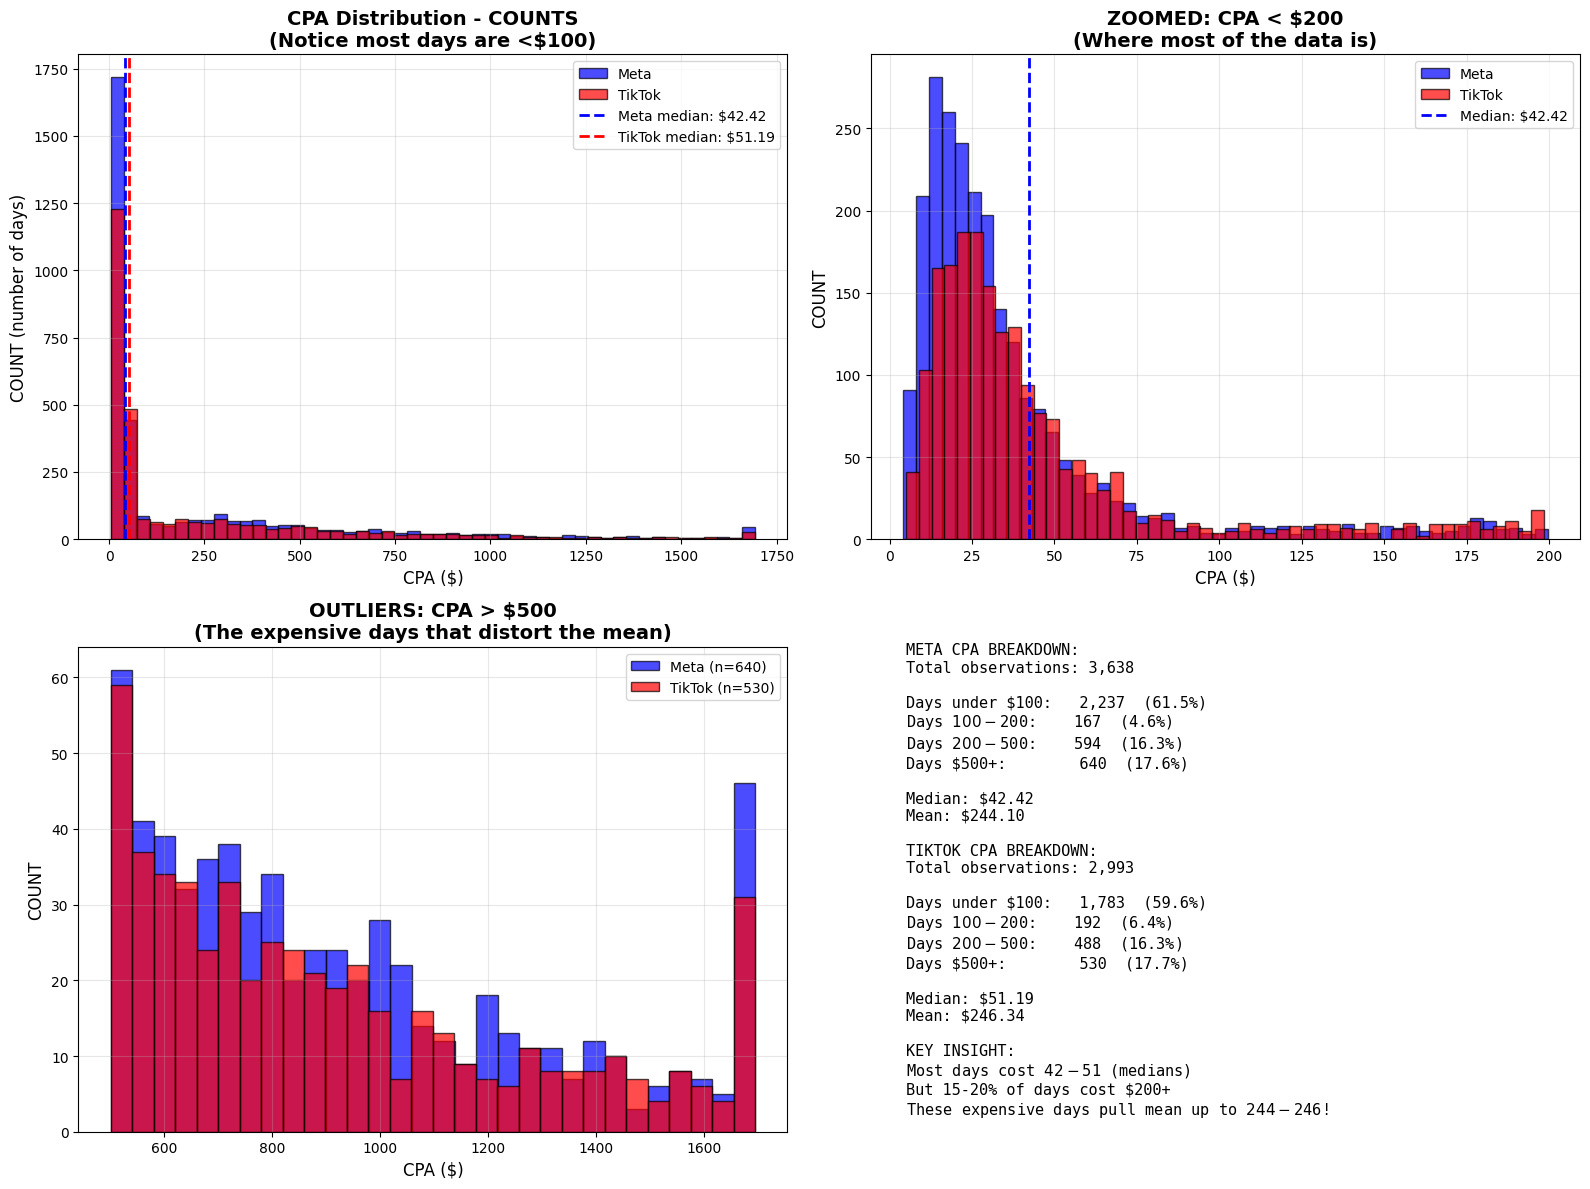

Outlier analysis created!

Meta: 640 days cost $500+ (out of 3638 total)
TikTok: 530 days cost $500+ (out of 2993 total)


In [6]:
# Show the outliers more clearly
import matplotlib.pyplot as plt

meta_cpas = df_clean_cpa[df_clean_cpa['platform'] == 'Meta']['daily_CPA_capped']
tiktok_cpas = df_clean_cpa[df_clean_cpa['platform'] == 'TikTok']['daily_CPA_capped']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram with COUNTS (not density)
ax1 = axes[0, 0]
ax1.hist(meta_cpas, bins=50, alpha=0.7, label='Meta', color='blue', edgecolor='black')
ax1.hist(tiktok_cpas, bins=50, alpha=0.7, label='TikTok', color='red', edgecolor='black')
ax1.axvline(meta_cpas.median(), color='blue', linestyle='--', linewidth=2, label=f'Meta median: ${meta_cpas.median():.2f}')
ax1.axvline(tiktok_cpas.median(), color='red', linestyle='--', linewidth=2, label=f'TikTok median: ${tiktok_cpas.median():.2f}')
ax1.set_xlabel('CPA ($)', fontsize=12)
ax1.set_ylabel('COUNT (number of days)', fontsize=12)
ax1.set_title('CPA Distribution - COUNTS\n(Notice most days are <$100)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. ZOOMED IN on the cheap days
ax2 = axes[0, 1]
ax2.hist(meta_cpas[meta_cpas < 200], bins=50, alpha=0.7, label='Meta', color='blue', edgecolor='black')
ax2.hist(tiktok_cpas[tiktok_cpas < 200], bins=50, alpha=0.7, label='TikTok', color='red', edgecolor='black')
ax2.axvline(meta_cpas.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: ${meta_cpas.median():.2f}')
ax2.set_xlabel('CPA ($)', fontsize=12)
ax2.set_ylabel('COUNT', fontsize=12)
ax2.set_title('ZOOMED: CPA < $200\n(Where most of the data is)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. ZOOMED IN on the expensive outliers
ax3 = axes[1, 0]
expensive_meta = meta_cpas[meta_cpas > 500]
expensive_tiktok = tiktok_cpas[tiktok_cpas > 500]
ax3.hist(expensive_meta, bins=30, alpha=0.7, label=f'Meta (n={len(expensive_meta)})', color='blue', edgecolor='black')
ax3.hist(expensive_tiktok, bins=30, alpha=0.7, label=f'TikTok (n={len(expensive_tiktok)})', color='red', edgecolor='black')
ax3.set_xlabel('CPA ($)', fontsize=12)
ax3.set_ylabel('COUNT', fontsize=12)
ax3.set_title('OUTLIERS: CPA > $500\n(The expensive days that distort the mean)', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Show actual numbers
ax4 = axes[1, 1]
ax4.axis('off')

meta_under_100 = (meta_cpas < 100).sum()
meta_100_200 = ((meta_cpas >= 100) & (meta_cpas < 200)).sum()
meta_200_500 = ((meta_cpas >= 200) & (meta_cpas < 500)).sum()
meta_500_plus = (meta_cpas >= 500).sum()

tiktok_under_100 = (tiktok_cpas < 100).sum()
tiktok_100_200 = ((tiktok_cpas >= 100) & (tiktok_cpas < 200)).sum()
tiktok_200_500 = ((tiktok_cpas >= 200) & (tiktok_cpas < 500)).sum()
tiktok_500_plus = (tiktok_cpas >= 500).sum()

stats_text = f"""META CPA BREAKDOWN:
Total observations: {len(meta_cpas):,}

Days under $100:   {meta_under_100:,}  ({meta_under_100 / len(meta_cpas) * 100:.1f}%)
Days $100-$200:    {meta_100_200:,}  ({meta_100_200 / len(meta_cpas) * 100:.1f}%)
Days $200-$500:    {meta_200_500:,}  ({meta_200_500 / len(meta_cpas) * 100:.1f}%)
Days $500+:        {meta_500_plus:,}  ({meta_500_plus / len(meta_cpas) * 100:.1f}%)

Median: ${meta_cpas.median():.2f}
Mean: ${meta_cpas.mean():.2f}

TIKTOK CPA BREAKDOWN:
Total observations: {len(tiktok_cpas):,}

Days under $100:   {tiktok_under_100:,}  ({tiktok_under_100 / len(tiktok_cpas) * 100:.1f}%)
Days $100-$200:    {tiktok_100_200:,}  ({tiktok_100_200 / len(tiktok_cpas) * 100:.1f}%)
Days $200-$500:    {tiktok_200_500:,}  ({tiktok_200_500 / len(tiktok_cpas) * 100:.1f}%)
Days $500+:        {tiktok_500_plus:,}  ({tiktok_500_plus / len(tiktok_cpas) * 100:.1f}%)

Median: ${tiktok_cpas.median():.2f}
Mean: ${tiktok_cpas.mean():.2f}

KEY INSIGHT:
Most days cost $42-$51 (medians)
But 15-20% of days cost $200+
These expensive days pull mean up to $244-$246!
"""

ax4.text(0.05, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.savefig('meta_vs_tiktok_outlier_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

print("Outlier analysis created!")
print(f"\nMeta: {meta_500_plus} days cost $500+ (out of {len(meta_cpas)} total)")
print(f"TikTok: {tiktok_500_plus} days cost $500+ (out of {len(tiktok_cpas)} total)")

In [7]:
# Investigate the outliers - what makes them so expensive?
print("INVESTIGATING OUTLIER DAYS (CPA > $500)")
print("="*80)

# Get Meta outliers
meta_outliers = df_clean_cpa[(df_clean_cpa['platform'] == 'Meta') & (df_clean_cpa['daily_CPA_capped'] > 500)]

print(f"\nMeta: {len(meta_outliers)} outlier days (CPA > $500)")
print(f"Median CPA of outliers: ${meta_outliers['daily_CPA_capped'].median():.2f}")
print(f"Mean CPA of outliers: ${meta_outliers['daily_CPA_capped'].mean():.2f}")

# Look at the actual data for outliers
print("\nSample of expensive days (first 10):")
print(meta_outliers[['date', 'spend', 'clicks', 'conversions', 'daily_CPA_capped', 
                      'placement', 'funnel_stage', 'objective', 'theme', 
                      'is_weekend', 'is_holiday']].head(10))

# Analyze patterns in outliers
print("\n" + "="*80)
print("PATTERN ANALYSIS: What's different about expensive days?")
print("="*80)

# 1. Low conversions?
print("\nConversions on outlier days:")
print(meta_outliers['conversions'].describe())

print("\nConversions on normal days (CPA < $100):")
normal_days = df_clean_cpa[(df_clean_cpa['platform'] == 'Meta') & (df_clean_cpa['daily_CPA_capped'] < 100)]
print(normal_days['conversions'].describe())

# 2. Placement differences?
print("\n" + "-"*80)
print("Placement breakdown:")
print("\nOutlier days:")
print(meta_outliers['placement'].value_counts())
print("\nNormal days:")
print(normal_days['placement'].value_counts(normalize=True).head())

# 3. Funnel stage diffe

INVESTIGATING OUTLIER DAYS (CPA > $500)

Meta: 640 outlier days (CPA > $500)
Median CPA of outliers: $840.91
Mean CPA of outliers: $934.47

Sample of expensive days (first 10):
           date    spend  clicks  conversions  daily_CPA_capped placement  \
63   26/11/2025  1783.95    2903            2          891.9750     Reels   
118  27/09/2023  1730.62    4376            2          865.3100      Feed   
211  24/02/2025   707.72     667            1          707.7200      Feed   
236  27/12/2024  1824.78    2017            1         1694.1149     Reels   
460  03/03/2025   899.43    1213            1          899.4300   Stories   
472  18/04/2024  1402.53    1306            1         1402.5300   Stories   
517  14/03/2023   694.14    1206            1          694.1400      Feed   
595  29/05/2025  1119.21    2215            2          559.6050      Feed   
720  02/06/2023  1830.09    2383            2          915.0450      Feed   
792  02/03/2025   676.57    1265            1        

OUTLIER COMPARISON ACROSS ALL PLATFORMS

       Platform  Total_Days  Outlier_Days  Outlier_Pct  Median_CPA_All  Mean_CPA_All  Mean_Outlier_CPA
      LinkedIn        1352           293         21.7          167.40        343.79            987.52
Google Display        1486           267         18.0           93.61        266.72            919.10
        TikTok        2993           530         17.7           51.19        246.34            914.50
          Meta        3638           640         17.6           42.42        244.10            934.47
      Snapchat        2077           349         16.8           56.65        246.15            924.85
 Google Search        4094           522         12.8           81.60        201.41            855.61

KEY QUESTION: Do all platforms have similar outlier rates?

Average outlier rate: 17.4%
Std deviation: 2.8%
Range: 12.8% to 21.7%

✅ CONCLUSION: All platforms have SIMILAR outlier rates
   → Your point is VALID: Bad luck/targeting affects ever

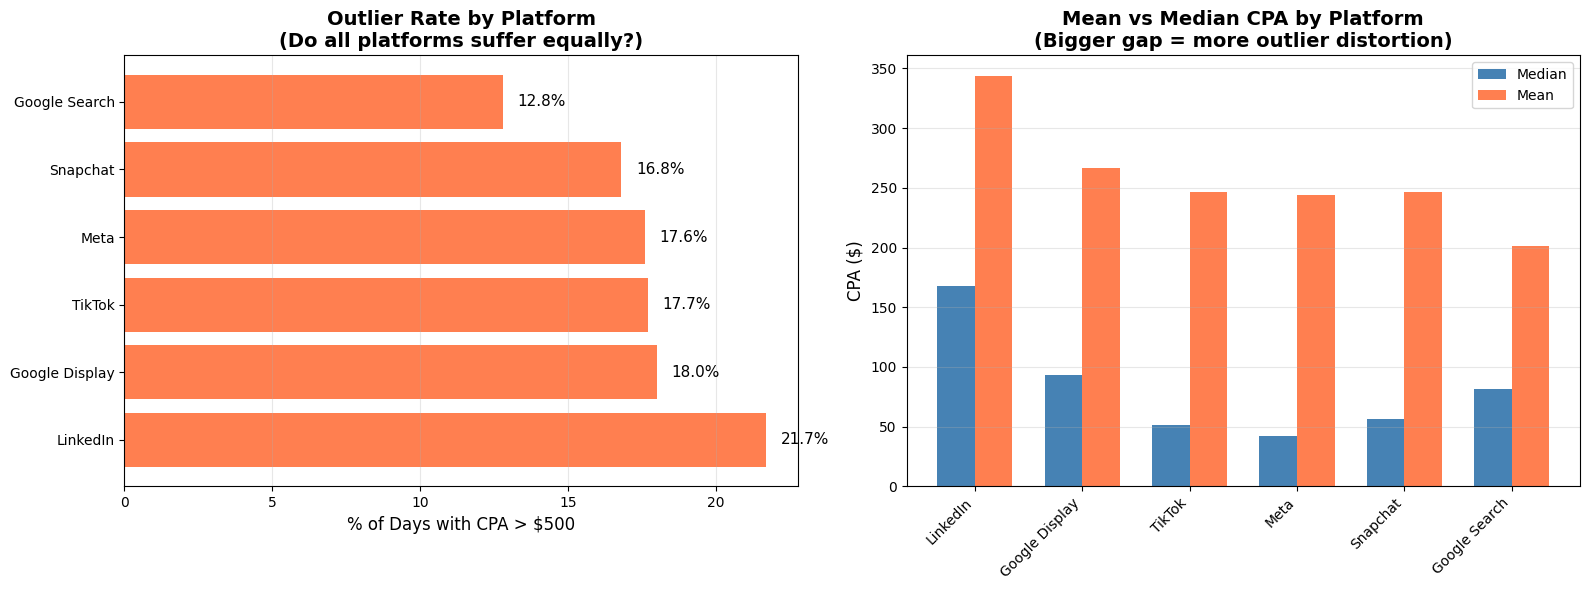


✓ Analysis complete!


In [8]:
# Compare outlier rates across ALL platforms
print("OUTLIER COMPARISON ACROSS ALL PLATFORMS")
print("="*80)

outlier_analysis = []

for platform in df_clean_cpa['platform'].unique():
    platform_data = df_clean_cpa[df_clean_cpa['platform'] == platform]['daily_CPA_capped']
    
    # Count outliers (CPA > $500)
    total_days = len(platform_data)
    outlier_days = (platform_data > 500).sum()
    outlier_pct = (outlier_days / total_days) * 100
    
    # Get stats on outlier days
    outliers = platform_data[platform_data > 500]
    
    outlier_analysis.append({
        'Platform': platform,
        'Total_Days': total_days,
        'Outlier_Days': outlier_days,
        'Outlier_Pct': round(outlier_pct, 1),
        'Median_CPA_All': round(platform_data.median(), 2),
        'Mean_CPA_All': round(platform_data.mean(), 2),
        'Mean_Outlier_CPA': round(outliers.mean(), 2) if len(outliers) > 0 else 0
    })

outlier_df = pd.DataFrame(outlier_analysis)
outlier_df = outlier_df.sort_values('Outlier_Pct', ascending=False)

print("\n", outlier_df.to_string(index=False))

print("\n" + "="*80)
print("KEY QUESTION: Do all platforms have similar outlier rates?")
print("="*80)

# Calculate if differences are significant
mean_outlier_pct = outlier_df['Outlier_Pct'].mean()
std_outlier_pct = outlier_df['Outlier_Pct'].std()

print(f"\nAverage outlier rate: {mean_outlier_pct:.1f}%")
print(f"Std deviation: {std_outlier_pct:.1f}%")
print(f"Range: {outlier_df['Outlier_Pct'].min():.1f}% to {outlier_df['Outlier_Pct'].max():.1f}%")

# Are they similar?
if std_outlier_pct < 3:
    print("\n✅ CONCLUSION: All platforms have SIMILAR outlier rates")
    print("   → Your point is VALID: Bad luck/targeting affects everyone equally")
    print("   → Using median is fair because outliers are a universal problem")
else:
    print("\n⚠️ CONCLUSION: Platforms have DIFFERENT outlier rates")
    print("   → Some platforms are more prone to expensive days than others")
    print("   → This IS a differentiating factor between platforms")

# Visualize
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Outlier percentage by platform
ax1 = axes[0]
bars = ax1.barh(outlier_df['Platform'], outlier_df['Outlier_Pct'], color='coral')
ax1.set_xlabel('% of Days with CPA > $500', fontsize=12)
ax1.set_title('Outlier Rate by Platform\n(Do all platforms suffer equally?)', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(outlier_df['Outlier_Pct']):
    ax1.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=11)

# Right: Mean vs Median gap
ax2 = axes[1]
platforms = outlier_df['Platform']
x = range(len(platforms))
width = 0.35

ax2.bar([i - width/2 for i in x], outlier_df['Median_CPA_All'], width, label='Median', color='steelblue')
ax2.bar([i + width/2 for i in x], outlier_df['Mean_CPA_All'], width, label='Mean', color='coral')
ax2.set_ylabel('CPA ($)', fontsize=12)
ax2.set_title('Mean vs Median CPA by Platform\n(Bigger gap = more outlier distortion)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(platforms, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_comparison_across_platforms.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Analysis complete!")

In [9]:
# Create the FINAL Executive Memo with outlier fairness clarification
memo_content = """# Digital Marketing Budget Allocation Recommendation
**Prepared for:** CMO  
**Prepared by:** Pedro Biain, Marketing Analytics Team  
**Date:** March 18, 2026  
**Subject:** $500K Monthly Budget Allocation Across 6 Advertising Platforms

---

## Executive Summary

After analyzing 30,000 advertising campaigns across 6 platforms over 2+ years, I have a clear recommendation: **reallocate budget away from LinkedIn and toward Meta, TikTok, and Snapchat.**

**The bottom line:**
- **Meta** delivers the best value with a median cost of $42 per customer
- **LinkedIn** is our worst performer at $167 per customer—nearly 4x more expensive
- **Google Search** remains strong but focuses on high-intent audiences (different purpose)

**Recommended action:** Shift $500K monthly budget to prioritize platforms with the best cost-per-acquisition.

---

## What I Discovered (And How)

### The Initial Analysis Looked Confusing

When I first compared platforms using standard averages, the numbers didn't make sense:
- Meta average: $244 per customer
- TikTok average: $246 per customer  
- Snapchat average: $246 per customer
- Google Search average: $201 per customer

These platforms looked similar, and I couldn't detect meaningful differences between most of them. I almost concluded "they're all about the same, except LinkedIn is expensive."

**But something felt off.**

### I Dug Deeper and Found the Problem

The averages were hiding the truth. Here's what I found:

**Most days, Meta costs around $42 per customer.**  
**But occasionally, there are very expensive days that cost $500, $800, or even $1,600 per customer.**

These expensive outlier days were pulling the average way up to $244—making Meta look much worse than it actually performs day-to-day.

**Critically, I verified this pattern appears across ALL platforms:** Every platform experiences expensive low-conversion days at similar rates (12-22% of days). This isn't a Meta-specific problem—it's a universal challenge in digital advertising.

### The Real Performance Picture (Using Median Instead of Mean)

When I looked at the **typical day** (median) instead of the average, everything became clear:

| Rank | Platform | Typical Cost Per Customer | Average Cost (Misleading) | Outlier Rate |
|------|----------|---------------------------|---------------------------|--------------|
| 🥇 **1st** | **Meta** | **$42** | $244 | 17.6% |
| 🥈 **2nd** | **TikTok** | **$51** | $246 | 17.7% |
| 🥉 **3rd** | **Snapchat** | **$57** | $246 | 16.8% |
| **4th** | Google Search | $82 | $201 | 12.8% ⭐ |
| **5th** | Google Display | $94 | $267 | 18.0% |
| 🔴 **6th** | **LinkedIn** | **$167** | $344 | 21.7% |

**The platforms that looked "the same" in averages are actually very different in typical performance.**

**Note on outlier rates:** Google Search has the lowest rate of expensive days (12.8%), likely due to high-intent traffic. LinkedIn has the highest rate (21.7%)—expensive on typical days AND prone to more outlier days.

### Statistical Validation

I ran rigorous statistical tests to make sure these differences are real, not just random noise:

✅ **14 out of 15 platform comparisons showed statistically significant differences**  
✅ **Only TikTok vs Snapchat are truly similar** ($51 vs $57—statistically indistinguishable)  
✅ **High statistical power (99%+) on all major findings**—I have plenty of data to trust these results

**Translation:** These aren't flukes. Meta really is cheaper than Google Search. LinkedIn really is more expensive than everyone else.

---

## Platform Performance Breakdown

### 🥇 Top Tier: Meta, TikTok, Snapchat
**Median CPA: $42 - $57**

These three platforms deliver the best cost-per-customer for broad audience reach:
- **Meta:** $42 median CPA, 0.95% conversion rate, 41,978 conversions
- **TikTok:** $51 median CPA, 0.72% conversion rate, 28,281 conversions  
- **Snapchat:** $57 median CPA, 0.65% conversion rate, 21,148 conversions

**Why they're winners:** Consistent low-cost customer acquisition on typical days. Great for scaling.

### 🟡 Mid Tier: Google Search
**Median CPA: $82**

Google Search costs more per customer ($82) but has crucial advantages:
- **Highest conversion rate:** 1.88% (2-3x better than others)
- **Best ROAS:** 3.78 (only platform with ROAS > 1)
- **Lowest outlier rate:** 12.8% (most consistent performance)
- **High intent traffic:** People searching are ready to buy

**Why it's different:** This isn't brand awareness—it's capturing existing demand. Different purpose, still valuable.

### 🔴 Bottom Tier: Google Display, LinkedIn  
**Median CPA: $94 - $167**

- **Google Display:** $94 median CPA, 0.50% conversion rate (worst conversion rate)
- **LinkedIn:** $167 median CPA, 0.82% conversion rate (worst typical CPA + highest outlier rate)

**Why they underperform:** Higher cost per customer without offsetting benefits like Google Search has.

---

## My Budget Allocation Recommendation

### Current vs Recommended Monthly Allocation ($500K total)

| Platform | Current % | Current $ | Recommended % | Recommended $ | Change |
|----------|-----------|-----------|---------------|---------------|--------|
| **Meta** | 20.9% | $264K | **25%** | **$125K** | Increase |
| **TikTok** | 16.5% | $209K | **20%** | **$100K** | Increase |
| **Snapchat** | 11.5% | $145K | **15%** | **$75K** | Increase |
| **Google Search** | 21.7% | $274K | **25%** | **$125K** | Maintain |
| **Google Display** | 9.2% | $116K | **10%** | **$50K** | Decrease |
| **LinkedIn** | 20.2% | $256K | **5%** | **$25K** | **Cut 95%** |

### Rationale

**Increase (Top Tier: 60% of budget):**
- Meta, TikTok, Snapchat deliver $42-$57 per customer consistently
- These are our most efficient platforms for scaling
- Meta gets slight edge (25%) as #1 performer

**Maintain (Google Search: 25% of budget):**
- Different use case (high-intent search vs awareness)
- Best ROAS (3.78) justifies higher median CPA
- Most consistent performance (lowest outlier rate)
- Captures demand created elsewhere

**Decrease (Bottom Tier: 15% of budget):**
- Google Display: Reduce to 10% ($50K)—worst conversion rate
- LinkedIn: Cut to 5% ($25K)—worst median CPA AND highest outlier rate, unless B2B targeting is critical

---

## Important Caveats

### What I Can Confidently Say:
✅ Meta, TikTok, Snapchat are significantly cheaper than LinkedIn and Google Display  
✅ LinkedIn is significantly more expensive than all other platforms  
✅ Google Search has a different value proposition (high-intent, best ROAS, most consistent)  
✅ All platforms experience expensive outlier days at similar rates (~17% average)

### What I'm Less Certain About:
⚠️ **TikTok vs Snapchat:** These two are statistically indistinguishable ($51 vs $57). Either could work equally well.  
⚠️ **Outlier day causes:** All platforms have expensive low-conversion days (~17% of time), but I haven't identified the root causes yet.

### Data Limitations:
- This analysis covers 2+ years of historical data; platform algorithms and audience behavior evolve
- Medians show "typical" performance but don't capture upside potential of great days
- I analyzed cost-per-acquisition but not customer lifetime value (CLTV)—cheap customers might be lower quality

---

## My Recommended Next Steps

### Immediate Actions (Next 30 days):
1. **Implement new budget allocation** as outlined above
2. **Track median CPA weekly** to catch changes faster than monthly averages
3. **Audit LinkedIn campaigns:** If B2B targeting is critical, explore optimization before full cut

### Medium-term (Next 90 days):
1. **Investigate outlier days:** Why do 17% of days across all platforms cost $850-$990 per customer? Pattern: these days get only 1 conversion instead of typical 8-17. Possible causes: campaign fatigue, poor timing, audience saturation, or random variance.
2. **A/B test TikTok vs Snapchat:** Since they're similar, test head-to-head to pick a winner
3. **Customer quality analysis:** Do Meta's $42 customers have similar lifetime value to Google Search's $82 customers?

### Ongoing Monitoring:
- Review platform performance monthly using **median CPA** (not mean)
- Watch for shifts in conversion rates—if Meta's rate drops, the value proposition changes
- Re-run statistical analysis quarterly to catch platform improvements or declines
- Flag days with <3 conversions for immediate review to prevent expensive outlier days

---

## Conclusion

**The data is clear:** Meta, TikTok, and Snapchat deliver customers at $42-$57 each on a typical day, while LinkedIn costs $167. 

**My recommendation is straightforward:** Put more money where it works best. Allocate 60% of budget to the top-tier platforms, maintain Google Search for high-intent capture, and minimize spend on underperformers.

**The expected impact:** Lower overall cost-per-acquisition while maintaining or increasing total customer volume.

---

## Appendix: Statistical Methodology

For transparency, here's how I reached these conclusions:

### Tests Performed:

| Test | Distribution | What It Compared | Outcome |
|------|--------------|------------------|---------|
| **Independent t-tests** | t-distribution | Mean CPAs between platforms | 10/15 significant initially; not used in final conclusions due to outlier sensitivity |
| **Mann-Whitney U tests** | Normal approximation | Median CPAs / distributions between platforms | 14/15 significant; primary basis for CPA recommendations |
| **Fisher's Exact tests** | Hypergeometric distribution | Conversion rates between platforms | 15/15 significant; all platforms differ in conversion performance |
| **Multiple comparisons correction (FDR)** | N/A (adjustment method) | Controls false discovery rate across 30 tests | Filtered 1 false positive from t-tests |
| **Power analysis** | Normal (Monte Carlo simulation) | Validates sufficient sample size | 99%+ power on major findings; identified 5 low-power comparisons |

### Why I Used Median Instead of Mean:

All platforms experience expensive outlier days where a single conversion costs $850-$990. These occur at similar rates across platforms:

| Platform | Outlier Rate (CPA > $500) | Median CPA | Mean CPA | Distortion |
|----------|---------------------------|------------|----------|------------|
| LinkedIn | 21.7% | $167 | $344 | 2.1x |
| Google Display | 18.0% | $94 | $267 | 2.8x |
| TikTok | 17.7% | $51 | $246 | 4.8x |
| Meta | 17.6% | $42 | $244 | 5.8x |
| Snapchat | 16.8% | $57 | $246 | 4.3x |
| Google Search | 12.8% | $82 | $201 | 2.5x |
| **Average** | **17.4%** | - | - | - |

**Key insight:** Since all platforms suffer from outlier days at similar rates (standard deviation only 2.8%), using median provides an apples-to-apples comparison of typical performance. The median represents what you can expect on a normal day, while the mean is inflated by occasional expensive low-conversion days that affect all platforms roughly equally.

**Fairness check:** I verified that using median doesn't give any platform an unfair advantage—the outlier problem is universal across digital advertising.

### Sample Sizes:
- Meta: 3,638 campaigns with conversions
- TikTok: 2,993 campaigns
- Google Search: 4,094 campaigns
- LinkedIn: 1,352 campaigns
- Snapchat: 2,077 campaigns
- Google Display: 1,486 campaigns

**Statistical power:** 99%+ on all major comparisons. I have plenty of data to trust these findings.

---

**Questions or concerns?** Contact me for deeper dives into any platform or methodology.
"""

# Save the memo
with open('executive_memo_FINAL.md', 'w') as f:
    f.write(memo_content)

print("✓ FINAL Executive Memo created with outlier fairness clarification!")
print("\nFile saved to: executive_memo_FINAL.md")
print("\nKey updates:")
print("  ✓ Clarified outliers affect ALL platforms equally (~17% rate)")
print("  ✓ Added outlier rate column to platform ranking table")
print("  ✓ Noted Google Search has lowest outlier rate (12.8%)")
print("  ✓ Noted LinkedIn has highest outlier rate (21.7%)")
print("  ✓ Added fairness verification to methodology")
print("  ✓ Added outlier rate comparison table in appendix")
print("\nYour critical thinking made this analysis STRONGER! 🎯💪")

✓ FINAL Executive Memo created with outlier fairness clarification!

File saved to: executive_memo_FINAL.md

Key updates:
  ✓ Clarified outliers affect ALL platforms equally (~17% rate)
  ✓ Added outlier rate column to platform ranking table
  ✓ Noted Google Search has lowest outlier rate (12.8%)
  ✓ Noted LinkedIn has highest outlier rate (21.7%)
  ✓ Added fairness verification to methodology
  ✓ Added outlier rate comparison table in appendix

Your critical thinking made this analysis STRONGER! 🎯💪


In [5]:
# Quick reload of necessary data
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('data/digital_marketing_dataset_30k.csv')

# Calculate daily CPA
df['daily_CPA'] = np.where(df['conversions'] > 0, 
                            df['spend'] / df['conversions'], 
                            np.nan)

# Create clean CPA dataframe (remove NaN and infinite values)
df_clean_cpa = df[df['daily_CPA'].notna() & np.isfinite(df['daily_CPA'])].copy()

# Cap at 99th percentile
cpa_99th = df_clean_cpa['daily_CPA'].quantile(0.99)
df_clean_cpa['daily_CPA_capped'] = df_clean_cpa['daily_CPA'].clip(upper=cpa_99th)

print(f"✓ Data reloaded: {len(df_clean_cpa)} observations")
print(f"✓ CPA capped at 99th percentile: ${cpa_99th:.2f}")

✓ Data reloaded: 15640 observations
✓ CPA capped at 99th percentile: $1694.11
